In [ ]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


# Check to see if we're running in Colab (versus local server)

In [ ]:
try:
  from google.colab import drive
  IN_COLAB=True
except:
  IN_COLAB=False

if IN_COLAB:
  print("We're running Colab")

We're running Colab


# Tensorflow with GPU

This notebook provides an introduction to computing on a [GPU](https://cloud.google.com/gpu) in Colab. In this notebook you will connect to a GPU, and then run some basic TensorFlow operations on both the CPU and a GPU, observing the speedup provided by using the GPU.


## Enabling and testing the GPU

First, you'll need to enable GPUs for the notebook:

- Navigate to Edit→Notebook Settings
- select GPU from the Hardware Accelerator drop-down

Next, we'll confirm that we can connect to the GPU with tensorflow:

In [ ]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


## Observe TensorFlow speedup on GPU relative to CPU

This example constructs a typical convolutional neural network layer over a
random image and manually places the resulting ops on either the CPU or the GPU
to compare execution speed.

In [ ]:
import tensorflow as tf
import timeit

device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print(
      '\n\nThis error most likely means that this notebook is not '
      'configured to use a GPU.  Change this in Notebook Settings via the '
      'command palette (cmd/ctrl-shift-P) or the Edit menu.\n\n')
  raise SystemError('GPU device not found')

def cpu():
  with tf.device('/cpu:0'):
    random_image_cpu = tf.random.normal((100, 100, 100, 3))
    net_cpu = tf.keras.layers.Conv2D(32, 7)(random_image_cpu)
    return tf.math.reduce_sum(net_cpu)

def gpu():
  with tf.device('/device:GPU:0'):
    random_image_gpu = tf.random.normal((100, 100, 100, 3))
    net_gpu = tf.keras.layers.Conv2D(32, 7)(random_image_gpu)
    return tf.math.reduce_sum(net_gpu)

# We run each op once to warm up; see: https://stackoverflow.com/a/45067900
cpu()
gpu()

# Run the op several times.
print('Time (s) to convolve 32x7x7x3 filter over random 100x100x100x3 images '
      '(batch x height x width x channel). Sum of ten runs.')
print('CPU (s):')
cpu_time = timeit.timeit('cpu()', number=10, setup="from __main__ import cpu")
print(cpu_time)
print('GPU (s):')
gpu_time = timeit.timeit('gpu()', number=10, setup="from __main__ import gpu")
print(gpu_time)
print('GPU speedup over CPU: {}x'.format(int(cpu_time/gpu_time)))

Time (s) to convolve 32x7x7x3 filter over random 100x100x100x3 images (batch x height x width x channel). Sum of ten runs.
CPU (s):
0.18901824299973669
GPU (s):
0.18930168300084915
GPU speedup over CPU: 0x


# Start of the code

In [ ]:
import os
# import tensorflow.compat.v1 as tf #import tensorflow as tf by CHS
import tensorflow as tf # by CHS
from tensorflow.keras.utils import to_categorical #from keras.utils import to_categorical by CHS
import glob
import cv2
import numpy as np
import time
import inspect

tf.compat.v1.disable_eager_execution() #by CHS
tf.compat.v1.disable_v2_behavior() #CHS

Instructions for updating:
non-resource variables are not supported in the long term


In [ ]:
ls

sample_data/


In [ ]:
def data_normalizer(data): # by CHS 20221122-24 to make all values into numbers between 0 and 1: from 0 to 255 into between 0 and 1 by dividing 255 to all values
  import numpy as np

  data_normalized = data/(np.max(data)-np.min(data)) # 255 - 0 = 255
  return data_normalized

# **Dataset: TAU 2024-09-05 Start**

In [ ]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
# VGG_MEAN = [103.939, 116.779, 123.68]


def load_audio_data(data_normal_flag=True): # by CHS #data_normal_flag=True by CHS 20221122
    #dirs = ['Air Conditioner', 'Car Horn', 'Children Playing', 'Dog Bark'] #21/11/2022 code run experiment
    #dirs = ['Car Horn', 'Children Playing', 'Dog Bark'] #21/11/2022 code run experiment
    # dirs = ['Air Conditioner', 'Car Horn', 'Children Playing', 'Dog Bark', 'Drilling', 'Engine Idling', 'Gun Shot', 'Jackhammer', 'Siren', 'Street Music']
    # [Hyosun] TAU dataset: 2024-09-07
    dirs = ['airport', 'bus', 'metro', 'metro_station', 'park', 'public_square', 'shopping_mall', 'street_pedestrian', 'street_traffic', 'tram']
    # [/Hyosun] TAU dataset: 2024-09-07
    data       = [] # by CHS
    lab = []
    data_files = [] #2024-09-15

    import random #[Hyosun] add 2024-09-07
    i = 0 # The label index in the order above in dirs
    for dir_ in dirs:
        random.seed(306) #[Hyosun] add 2024-09-07
        # Python glob. glob() method returns a list of files or folders that matches the path specified in the pathname argument.
        # This function takes two arguments, namely pathname, and recursive flag.
        # pathname : Absolute (with full path and the file name) or relative (with UNIX shell-style wildcards)
        files = glob.glob(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/tau_images', dir_,'*.jpg')) #[Hyosun]remove .DS_Store first -> fixing the error sorted out!

        files_cnt_each_label = 0
        for file in files:
            # if files_cnt_each_label < 10000: # [Hyosun] added if statement 2024-09-07
            data.append(cv2.imread(file, 1))
            files_cnt_each_label += 1
            data_files.append(file) #2024-09-15
            # else:   # [Hyosun] added if statement 2024-09-07
            #     break
        # print("files_cnt_each_label: ", files_cnt_each_label) #[Hyosun] added 2024-09-07
        lab = np.append(lab, np.tile(i, files_cnt_each_label), axis = 0)
        # print("lab: ", lab)                                   #[Hyosun] added 2024-09-07
        i +=1
    labels = to_categorical(lab) # one-hot conversion # train, test: each 200 개씩 있음
    # data normalization by CHS 20221122 -------
    if data_normal_flag == True:
      data_normalized = data_normalizer(np.array(data))
    # ------------------------------------------
    # print("data_normalized:\n", np.array(data_normalized)[:10], "\n labels: \n", labels[:10]) #[Hyosun] added 2024-09-07
    return np.array(data_normalized), labels, data_files #data_files added 2024-09-15 # by CHS data-> data_normalized 20221122

In [ ]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
# VGG_MEAN = [103.939, 116.779, 123.68]

# This is also the right version of function confirmed by CHS 20221202
def load_audio_data_v2(test_fraction=0.2, data_normal_flag=True):
              #[Hyosun]test_fraction=0.2 modified 2024-09-07
    """ by CHS : data_normal_flag=True by CHS 20221122
               : test_fraction=0.3     by CHS 20221124
    """

    #dirs = ['Air Conditioner', 'Car Horn', 'Children Playing', 'Dog Bark'] #21/11/2022 code run experiment
    #dirs = ['Car Horn', 'Children Playing', 'Dog Bark'] #21/11/2022 code run experiment
    # [Hyosun] TAU dataset: 2024-09-07
    dirs = ['airport', 'bus', 'metro', 'metro_station', 'park', 'public_square', 'shopping_mall', 'street_pedestrian', 'street_traffic', 'tram']
    # [/Hyosun] TAU dataset: 2024-09-07
    data       = [] # by CHS
    data_train = []
    data_test  = []
    lab        = [] # by CHS : doesn't have to be numpy
    lab_train  = [] # by CHS
    lab_test   = [] # by CHS
    train_data_files = [] #2024-09-15
    test_data_files  = [] #2024-09-15

    import random #[Hyosun] add 2024-09-07
    i = 0 # The label index in the order above in dirs
    for dir_ in dirs: # [Hyosun] for each label folder
        random.seed(306) #[Hyosun] add 2024-09-07
        # Python glob. glob() method returns a list of files or folders that matches the path specified in the pathname argument.
        # This function takes two arguments, namely pathname, and recursive flag.
        # pathname : Absolute (with full path and the file name) or relative (with UNIX shell-style wildcards)
        files = glob.glob(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/tau_images', dir_,'*.jpg'))

        files_cnt_each_label = len(files) #0 #[Hyosun] 2024-09-13
        # data_each_label = [] # by CHS
        # lab_each_label  = [] # by CHS

        # split data(of each label) into train_set and test_set by CHS 20221124, moved up here 2024-09-13 ------------------------
        test_data_size_each_label  = int(files_cnt_each_label*test_fraction)
        train_data_size_each_label = files_cnt_each_label - test_data_size_each_label

        # make data, modified 2024-09-13
        for fi in range(0, train_data_size_each_label):
            # if files_cnt_each_label < 1000: # [Hyosun] added if statement 2024-09-07
            # data_each_label.append(cv2.imread(file, 1))
            data_train.append(cv2.imread(files[fi], 1))
            lab_train = np.append(lab_train, np.tile(i, 1), axis = 0)
            train_data_files.append(files[fi]) #2024-09-15
            # files_cnt_each_label += 1
            # else:   # [Hyosun] added if statement 2024-09-07
            #     break
        for fi in range(train_data_size_each_label, files_cnt_each_label):
            data_test.append(cv2.imread(files[fi], 1))
            lab_test = np.append(lab_test, np.tile(i, 1), axis = 0)
            test_data_files.append(files[fi])  #2024-09-15
        # # make labels, modified 2024-09-13
        # lab_train = np.tile(i, train_data_size_each_label)
        # lab_test  = np.tile(i,  test_data_size_each_label)

        # lab_each_label = np.tile(i, files_cnt_each_label)
        # lab_each_label = np.append(lab_each_label, np.tile(i, files_cnt_each_label), axis = 0)

        # # split data(of each label) into train_set and test_set by CHS 20221124 ------------------------
        # test_data_size_each_label  = int(files_cnt_each_label*test_fraction)
        # train_data_size_each_label = files_cnt_each_label - test_data_size_each_label

        #[Hyosun] print added 2024-09-13
        print("label dir_: %s\n files_cnt_each_label: %d\n train_data_size_each_label: %d\n test_data_size_each_label: %d\n" %(dir_, files_cnt_each_label, train_data_size_each_label, test_data_size_each_label) )
        #[Hyosun] print added 2024-09-14
        print("label dir_: %s\n len(data_train)+len(data_test): %d\n len(data_train): %d\n len(data_test): %d\n" %(dir_, len(data_train)+len(data_test), len(data_train), len(data_test)))
        print("label dir_: %s\n len(lab_train)+len(lab_test): %d\n len(lab_train): %d\n len(lab_test): %d\n" %(dir_, len(data_train)+len(data_test), len(data_train), len(data_test)))

        #[Hyosun] test 2024-09-13
        # data_train.extend(data_each_label[:train_data_size_each_label])
        # data_test.extend(data_each_label[train_data_size_each_label:])
        # lab_train.extend(lab_each_label[:train_data_size_each_label])
        # lab_test.extend(lab_each_label[train_data_size_each_label:])
        # data_train = data_each_label[:train_data_size_each_label]
        # data_test  = data_each_label[train_data_size_each_label:]
        # lab_train  = lab_each_label[:train_data_size_each_label]
        # lab_test   = lab_each_label[train_data_size_each_label:]
        #[/Hyosun] test 2024-09-13
        # -------------------------------------------------------------------------------

        i +=1

    labels_train = to_categorical(lab_train) # one-hot conversion
    labels_test  = to_categorical(lab_test)  # one-hot conversion

    train_size = len(lab_train)
    test_size  = len(lab_test)
    data_size  = train_size + test_size

    # data normalization by CHS 20221122 -------
    if data_normal_flag == True:
      #[Hyosun] added and modified 2024-09-14
      data = np.append(np.array(data_train), np.array(data_test), axis=0)
      data_normalized = data_normalizer(data)

      # data_train_normalized = data_normalizer(np.array(data_train))
      # data_test_normalized  = data_normalizer(np.array(data_test))
      data_train_normalized = data[:train_size]
      data_test_normalized  = data[train_size:]
      #[/Hyosun] added and modified 2024-09-14
    # ------------------------------------------

    #[Hyosun] print added 2024-09-13
    print("len(data_train_normalized): %d\n len(labels_train): %d\n len(data_test_normalized):%d\n len(labels_test):%d\n" %(len(data_train_normalized), len(labels_train), len(data_test_normalized), len(labels_test)))
    return np.array(data_train_normalized), labels_train, train_data_files, np.array(data_test_normalized), labels_test, test_data_files
    # train_data_files, test_data_files added 2024-09-15 # by CHS data-> data_normalized 20221122

In [ ]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
# VGG_MEAN = [103.939, 116.779, 123.68]

# [Hyosun] Mission not completed : Include Permutation of indices for this version of function 2024-09-14
# This is also the right version of function confirmed by CHS 20221202
def load_audio_data_v3(test_fraction=0.2, data_normal_flag=True):
              #[Hyosun]test_fraction=0.2 modified 2024-09-07
    """ by CHS : data_normal_flag=True by CHS 20221122
               : test_fraction=0.3     by CHS 20221124
    """

    #dirs = ['Air Conditioner', 'Car Horn', 'Children Playing', 'Dog Bark'] #21/11/2022 code run experiment
    #dirs = ['Car Horn', 'Children Playing', 'Dog Bark'] #21/11/2022 code run experiment
    # [Hyosun] TAU dataset: 2024-09-07
    dirs = ['airport', 'bus', 'metro', 'metro_station', 'park', 'public_square', 'shopping_mall', 'street_pedestrian', 'street_traffic', 'tram']
    # [/Hyosun] TAU dataset: 2024-09-07
    data       = [] # by CHS
    data_train = []
    data_test  = []
    lab        = [] # by CHS : doesn't have to be numpy
    lab_train  = [] # by CHS
    lab_test   = [] # by CHS

    import random #[Hyosun] add 2024-09-07
    i = 0 # The label index in the order above in dirs
    for dir_ in dirs: # [Hyosun] for each label folder
        random.seed(306) #[Hyosun] add 2024-09-07
        # Python glob. glob() method returns a list of files or folders that matches the path specified in the pathname argument.
        # This function takes two arguments, namely pathname, and recursive flag.
        # pathname : Absolute (with full path and the file name) or relative (with UNIX shell-style wildcards)
        files = glob.glob(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/tau_images', dir_,'*.jpg'))

        files_cnt_each_label = 0
        data_each_label = [] # by CHS
        lab_each_label  = [] # by CHS

        # make data
        for file in files:
            # if files_cnt_each_label < 1000: # [Hyosun] added if statement 2024-09-07
            data_each_label.append(cv2.imread(file, 1))
            files_cnt_each_label += 1
            # else:   # [Hyosun] added if statement 2024-09-07
            #     break
        # make labels
        lab_each_label = np.tile(i, files_cnt_each_label)
        # lab_each_label = np.append(lab_each_label, np.tile(i, files_cnt_each_label), axis = 0)

        # split data(of each label) into train_set and test_set by CHS 20221124 ------------------------
        test_data_size_each_label  = int(files_cnt_each_label*test_fraction)
        train_data_size_each_label = files_cnt_each_label - test_data_size_each_label

        data_train.extend(data_each_label[:train_data_size_each_label])
        data_test.extend(data_each_label[train_data_size_each_label:])
        lab_train.extend(lab_each_label[:train_data_size_each_label])
        lab_test.extend(lab_each_label[train_data_size_each_label:])
        # -------------------------------------------------------------------------------

        i +=1

    labels_train = to_categorical(lab_train) # one-hot conversion
    labels_test  = to_categorical(lab_test)  # one-hot conversion

    # data normalization by CHS 20221122 -------
    if data_normal_flag == True:
      data_train_normalized = data_normalizer(np.array(data_train))
      data_test_normalized  = data_normalizer(np.array(data_test))
    # ------------------------------------------
    return np.array(data_train_normalized), labels_train, np.array(data_test_normalized), labels_test  # by CHS data-> data_normalized 20221122

In [ ]:
# calculate acc, precision, recall score: 2024-09-15
def tf_f1_score(y_true, y_pred, num_classes): #num_classes added 2024-09-17
    import tensorflow as tf

    f1s = [0, 0, 0]
    # x_data = test_data
    # y_true = to_categorical(y_true) #test_labels
    y_pred = to_categorical(y_pred, num_classes) #predictions_test

    # y_t = tf.argmax(y_true, 1)
    # y_p = tf.argmax(y_pred, 1)
    y_true = tf.cast(y_true, tf.float64)
    y_pred = tf.cast(y_pred, tf.float64)

    print("y_true: ", y_true)
    print("y_pred: ", y_pred)
    # print("y_t: ", y_t)
    # print("y_p: ", y_p)
    # for i, axis in enumerate([None, 0]):
    TP = tf.math.count_nonzero(y_pred * y_true)# tf.count_nonzero(y_pred * y_true, axis=axis)
    FP = tf.math.count_nonzero(y_pred * (y_true - 1))# tf.count_nonzero(y_pred * (y_true - 1), axis=axis)
    FN = tf.math.count_nonzero((y_pred - 1) * y_true)# tf.count_nonzero((y_pred - 1) * y_true, axis=axis)
    # axis=0
    # TP = tf.math.count_nonzero(y_pred * y_true, axis=axis)# tf.count_nonzero(y_pred * y_true, axis=axis)
    # FP = tf.math.count_nonzero(y_pred * (y_true - 1), axis=axis)# tf.count_nonzero(y_pred * (y_true - 1), axis=axis)
    # FN = tf.math.count_nonzero((y_pred - 1) * y_true, axis=axis)# tf.count_nonzero((y_pred - 1) * y_true, axis=axis)

    # precision = TP / (TP + FP)
    precision = tf.divide(TP, TP + FP)
    # recall = TP / (TP + FN)
    recall = tf.divide(TP, TP + FN)
    f1 = tf.divide(2 * precision * recall , (precision + recall))

    # f1s[i] = tf.reduce_mean(f1)

    print("type(precision): ", type(precision))

    with tf.compat.v1.Session() as sess:
        print(sess.run(TP))
        print (TP.eval())
        print(sess.run(FP))
        print (FP.eval())
        print(sess.run(FN))
        print (FN.eval())
        print(sess.run(precision))
        print (precision.eval())
        print(sess.run(recall))
        print (recall.eval())
        print(sess.run(f1))
        print (f1.eval())

        # p, r, f = sess.run([precision, recall, f1])
        # r = str(sess.run(recall))
        # f = str(sess.run(f1))
    # weights = tf.reduce_sum(y_true, axis=0)
    # weights /= tf.reduce_sum(weights)

    # f1s[2] = tf.reduce_sum(f1 * weights)

    # micro, macro, weighted = f1s
        return sess.run(precision), sess.run(recall), sess.run(f1)#, micro, macro, weighted
        # return precision.eval(), recall.eval(), f1.eval()
        # return p, r, f#, micro, macro, weighted
        # return sess.run([precision, recall, f1])
      # print(np.array(precision))
      #     f1s[i] = tf.reduce_mean(f1)
      # import sklearn
      # sklearn.metrics.precision_score(y_t, y_p)
      # from sklearn.metrics import confusion_matrix, recall_score, precision_score
      # # tf.contrib.metrics.recall_score(y_t, y_p)
      # print('Recall: ', tf.contrib.metrics.recall_score(y_t, y_p))
      # print('Precision: ', tf.contrib.metrics.precision_score(y_t, y_p))
      # print("precision: ", precision) #%f, recall: %f, f1: %f, f1s: %f " %(np.array(precision)[0], np.array(recall)[0], np.array(f1)[0], np.array(f1s)[0]))

      # print("precision: %f, recall: %f, f1: %f, f1s: %f " %(np.array(precision)[0], np.array(recall)[0], np.array(f1)[0], np.array(f1s)[0]))



In [ ]:
# a = [1, 2, 3]
# # a = 1
# b = []
# b.extend(a)
# print(b)
# b.extend(a)
# print(b)

In [ ]:
# train_data, train_labels, train_data_files, test_data, test_labels, test_data_files = load_audio_data_v2()
# train_data_len = len(train_data)
# test_data_len  = len(test_data)

In [ ]:
data, labels, data_files = load_audio_data()
data_len = len(data)
labels_len  = len(labels)

In [ ]:
# print(data_len)
# # labels[-10:]

23035


In [ ]:
# print(len(train_data))
# print(len(test_data))
# print(len(train_data)+len(test_data))

In [ ]:
# train_data[-10:]

In [ ]:
# train_labels[-10:]

In [ ]:
# test_data[-10:]

In [ ]:
# test_labels[-10:]

In [ ]:
# test_labels[500]

In [ ]:
# print(np.min(train_data))
# print(np.max(train_data))
# print(np.min(test_data))
# print(np.max(test_data))

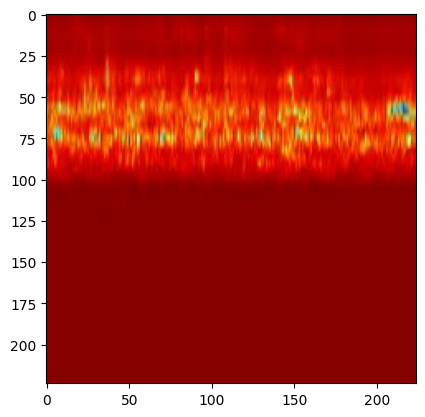

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(data[0])

In [ ]:
net = Vgg19(data_len=23035, no_labels=10, data_name="tau", load_data_version="v1", fusion_type="mean+max")

In [34]:
import keras
max_pool_2d = keras.layers.MaxPooling2D(pool_size=(1, 2),
   strides=(1, 2), padding="same")
results=max_pool_2d(data[:1])

In [41]:
results.numpy()

AttributeError: 'SymbolicTensor' object has no attribute 'numpy'

In [40]:
plt.imshow(results.numpy())

AttributeError: 'SymbolicTensor' object has no attribute 'numpy'

In [ ]:
# #[Hyosun] for maxpool(z1, T0) feature append
# def hmax_pool(bottom, name):      # instead of ksize=[1, 2, self.stride, 1], strides=[1, 2, self.stride, 1]
#     return tf.nn.max_pool2d(bottom, ksize=[1,1,32,1], strides=[1,1,32,1], padding='SAME', name=name)
net.hmax_pool(bottom = data[0], name="data0")

ValueError: ksize should be of length 1, 1 or 3. Received: ksize=[1, 1, 32, 1] of length 4

In [ ]:
class Vgg19(tf.keras.Model): #[Hyosun] tf.keras.Model added 2024-09-08
    def __init__(self, data_len=400, no_labels=10, vgg19_npy_path=None, data_name="", load_data_version="v1", fusion_type=""):
                     # data_len=400, no_labels=10,                     (data_name,    load_data_version added 2024-09-14,) fusion_type added(2024-09-03) by CHS
        super().__init__() #[Hyosun] tf.keras.Model added 2024-09-08
        try:
            # print("ls: ", ls)
            self.data_dict = np.load('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/vgg19.npy', allow_pickle=True, encoding='latin1').item() # , allow_pickle=True by CHS
            # The default allow_pickle was changed for safety reasons.
            # It reduces the chances of loading something bad from the file.
            # You have to explicitly allow a pickle load for a file from a trusted source.
            # Without pickle, the load can only be a safe, numeric (or string) array. – hpaulj  May 4, 2020 at 0:41
        except:
            print("Place vgg19.npy in the same directory as of this notebook.")
            print("You can get it from ")
        # self.var_dict = {} #[Hyosun] added 2024-09-08
        self.isTrain = True
        self.epochs = 80 #100 #80 #1 #60 #50 #1 #50 #the original epochs
        self.batch_size = 10
        # self.data_size = data_len #400 #[Hyosun] commented out 2024-09-14
        self.load_data_version = load_data_version #[Hyosun] added 2024-09-14
        self.restore = False
        self.decay = 0.99
        self.model_name = 'proposedVGG19'#'model' #2024-09-14
        self.ckpt_dir = '/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/' + self.model_name + "/checkpoint"
                                #'./' + self.model_name + "/checkpoint" #'/gdrive/MyDrive/ColabNotebooks/VGG19-Transfer-Learn-master/' by CHS
        self.test_fraction = 0.2 #[Hyosun] 2024-09-07 #0.5 # use the half of the train_set aas test_set (by CHS)
        self.no_labels = no_labels #2 #4 #10 # no_labels by CHS 21/11/2022
        # [Hyosun] for fusion added 2024-08-31
        self.layers_list = ["conv1_1", "conv1_1_relu", "conv1_2", "conv1_2_relu","pool1",
                            "conv2_1", "conv2_1_relu", "conv2_2", "conv2_2_relu", "pool2",
                            "conv3_1", "conv3_1_relu", "conv3_2", "conv3_2_relu", "conv3_3", "conv3_3_relu", "conv3_4", "conv3_4_relu", "pool3",
                            "conv4_1", "conv4_1_relu", "conv4_2", "conv4_2_relu", "conv4_3", "conv4_3_relu", "conv4_4", "conv4_4_relu", "pool4",
                            "conv5_1", "conv5_1_relu", "conv5_2", "conv5_2_relu", "conv5_3", "conv5_3_relu", "conv5_4", "conv5_4_relu", "pool5",
                            "fc6", "relu6", "fc7", "relu7", "fc8"]
        self.stride = 32
        # [/Hyosun] for fusion added 2024-08-31
        self.data_name   = data_name   #[Hyosun]data_name added 2024-09-14
        self.fusion_type = fusion_type #[Hyosun]fusion_type added 2024-09-03
    def model(self):
        """
        load variable from npy to build the VGG

        :param rgb: rgb image [batch, height, width, 3] values scaled [0, 1]
        """

        with tf.compat.v1.variable_scope('Input') as scope:   #.compat.v1 by CHS
            self.rgb = tf.compat.v1.placeholder(name = "Input", shape = [None, 224, 224, 3], dtype = tf.float32)  #[None, 224, 224, 3], dtype = tf.float32) by CHS #.compat.v1 by CHS
            self.labels = tf.compat.v1.placeholder(name = "Labels", shape = [None, self.no_labels], dtype = tf.float32) #4], dtype = tf.float32) #.compat.v1 by CHS
            self.isTrain = tf.compat.v1.placeholder(name = "isTrain", shape = None, dtype = tf.bool) #.compat.v1 by CHS
            self.step = tf.compat.v1.train.get_or_create_global_step() #tf.train.get_or_create_global_step() #.compat.v1 by CHS
            self.lr = tf.compat.v1.placeholder(name = "LR", shape = None, dtype = tf.float32) #.compat.v1 by CHS

        # Convert RGB to BGR
        red, green, blue = tf.split(axis=3, num_or_size_splits=3, value=self.rgb)
        bgr = tf.concat(axis=3, values=[
            blue,  # - VGG_MEAN[0], by CHS
            green, # - VGG_MEAN[1], by CHS
            red,   # - VGG_MEAN[2], by CHS
        ])

        # [Hyosun: comment] Conv block layers Start 2024-08-30 ================================
        # :param rgb: rgb image [batch, height=224, width=224, 3] values scaled [0, 1]
        fusion_layers=[17, 35, 40] #initial test, needs to find the best combination
        maxpool_layers = [4, 9, 18, 27, 36] #[Hyosun] should be modified for vgg19
        # outputs = [layer.output for layer in self.layers]
        # self.layers_list = [layer for layer in self.layers]
        print("self.layers_list: ", self.layers_list)
        self.features, self.stride = [], 32 #나는 32부터 시작
          # for l, m in enumerate(self.features.children()): #nn.Sequential안의 각 layer 별 내용들 m에 있다.
          #     x = m(x) # 각 layer 통과
          #     if l in maxpool_layers:
          #         stride = stride // 2
          #     if l in fusion_layers:  #(xT, xF)
          #         x_cur = F.max_pool2d(x, kernel_size=(stride, 1), stride=(stride, 1)) if stride > 1 else x.clone()
          #         B, xC, xT, xF = x_cur.shape
          #         x_cur = x_cur.transpose(2, 3).reshape(B, xC*xF, xT)
          #         features.append(x_cur)
        # [Hyosun: comment] Conv block layers End 2024-08-30

        self.conv1_1 = self.conv_layer(bgr, "conv1_1")
        self.conv1_2 = self.conv_layer(self.conv1_1, "conv1_2")
        self.pool1 = self.max_pool(self.conv1_2, 'pool1')


        # [Hyosun] testing 2024-08-30
        print("conv result, self.pool1.get_shape().as_list(): ", self.pool1.get_shape().as_list())  #, %d, %d, %d" % (B, xC, xT, xF))
        pool1_shape = self.pool1.get_shape().as_list()
        dim = 1
        for d in pool1_shape[1:]:
            dim *= d
        x = tf.reshape(self.pool1, [-1, dim])
        print("reshaped self.pool1: ", x.get_shape().as_list())
        # [/Hyosun] testing 2024-08-30

        self.conv2_1 = self.conv_layer(self.pool1, "conv2_1")
        self.conv2_2 = self.conv_layer(self.conv2_1, "conv2_2")
        self.pool2 = self.max_pool(self.conv2_2, 'pool2')


        # [Hyosun] testing 2024-08-30
        print("conv result, self.pool2.get_shape().as_list(): ", self.pool2.get_shape().as_list())  #, %d, %d, %d" % (B, xC, xT, xF))
        pool2_shape = self.pool2.get_shape().as_list()
        dim = 1
        for d in pool2_shape[1:]:
            dim *= d
        x = tf.reshape(self.pool2, [-1, dim])
        print("reshaped self.pool2: ", x.get_shape().as_list())
        # [/Hyosun] testing 2024-08-30

        self.conv3_1 = self.conv_layer(self.pool2, "conv3_1")
        self.conv3_2 = self.conv_layer(self.conv3_1, "conv3_2")
        self.conv3_3 = self.conv_layer(self.conv3_2, "conv3_3")
        self.conv3_4 = self.conv_layer(self.conv3_3, "conv3_4")
        self.pool3 = self.max_pool(self.conv3_4, 'pool3')


        # [Hyosun] testing 2024-08-30
        print("conv result, self.pool3.get_shape().as_list(): ", self.pool3.get_shape().as_list())  #, %d, %d, %d" % (B, xC, xT, xF))
        pool3_shape = self.pool3.get_shape().as_list()
        dim = 1
        for d in pool3_shape[1:]:
            dim *= d
        x = tf.reshape(self.pool3, [-1, dim])
        print("reshaped self.pool3: ", x.get_shape().as_list())
        # [/Hyosun] testing 2024-08-30

        self.conv4_1 = self.conv_layer(self.pool3, "conv4_1")
        self.conv4_2 = self.conv_layer(self.conv4_1, "conv4_2")
        self.conv4_3 = self.conv_layer(self.conv4_2, "conv4_3")
        self.conv4_4 = self.conv_layer(self.conv4_3, "conv4_4")
        self.pool4 = self.max_pool(self.conv4_4, 'pool4')

        output = self.pool4 # 이런식으로 저장해놓으면 되겠네.. 헐 쉽네..
        print("[Hyosun] output: ", output)
        # [Hyosun] testing 2024-08-30
        print("conv result, self.pool4.get_shape().as_list(): ", self.pool4.get_shape().as_list())  #, %d, %d, %d" % (B, xC, xT, xF))
        pool4_shape = self.pool4.get_shape().as_list()
        dim = 1
        for d in pool4_shape[1:]:
            dim *= d
        x = tf.reshape(self.pool4, [-1, dim])
        print("reshaped self.pool4: ", x.get_shape().as_list())
        # [/Hyosun] testing 2024-08-30

        self.conv5_1 = self.conv_layer(self.pool4, "conv5_1")
        self.conv5_2 = self.conv_layer(self.conv5_1, "conv5_2")
        self.conv5_3 = self.conv_layer(self.conv5_2, "conv5_3")
        self.conv5_4 = self.conv_layer(self.conv5_3, "conv5_4")
        self.pool5 = self.max_pool(self.conv5_4, 'pool5')

        # [Hyosun] testing 2024-08-30 여기 shape이 그 shape 이 아닌데..난 x의 shape이 필요함
        print("conv result, self.pool5.get_shape().as_list(): ", self.pool5.get_shape())  #, %d, %d, %d" % (B, xC, xT, xF))
        pool5_shape = self.pool5.get_shape().as_list()
        dim = 1
        for d in pool5_shape[1:]:
            dim *= d
        x = tf.reshape(self.pool5, [-1, dim])
        print("reshaped self.pool5: ", x.get_shape().as_list())
        # [/Hyosun] testing 2024-08-30

        # [Hyosun: comment] FC block Start 2024-08-30 ============================================
        # B, xC, xT, xF = self.pool5.shape #pytorch syntax
        # self.pool5.get_shape().as_list()

          # unsqueeze: torch.unsqueeze(input, dim) → Tensor
          #            :Returns a new tensor with a dimension of size one inserted at the specified position
          # fc1_1, relu1_1, fc1_2, relu1_2, fc2, relu2 = list(self.fc.children())
          # x = x.permute(0, 2, 3, 1).contiguous()
          # x = x.view(x.size(0), -1)
          # x = fc1_1(x)
          # x = relu1_1(x)
          # if 17 in layers:
          #     x_cur = x.unsqueeze(-1).expand(-1, -1, 6)
                        # unsqueeze 2차 dim으로 늘리고, #expand: -1 argument는 해당 dim에 변화주지 않는다는 의미. 즉 마지막 dim에만 사이즈 6로 값을 반복해서 늘리겠다는 의미
          #     features.append(x_cur)
          # x = fc1_2(x)
          # x = relu1_2(x)
          # if 19 in layers:
          #     x_cur = x.unsqueeze(-1).expand(-1, -1, 6)
          #     features.append(x_cur)
          # x = fc2(x)
          # x = relu2(x)
          # if 21 in layers:
          #     x_cur = x.unsqueeze(-1).expand(-1, -1, 6)
          #     features.append(x_cur)
          # # fusion -> [B, *, 6]
          # x = torch.hstack(features)
          # return x
        # [Hyosun: comment] FC block End 2024-08-30
        self.fc6 = self.fc_layer(self.pool5, "fc6")
        assert self.fc6.get_shape().as_list()[1:] == [4096]
        # [Hyosun] testing
        print("[Hyosun] self.fc6 shape: ", np.shape(self.fc6))
        print("[Hyosun] self.fc6.get_shape().as_list(): ", self.fc6.get_shape().as_list())
        print("[Hyosun] self.fc6 type: ",  type(self.fc6))
        #[/Hyosun] testing
        self.relu6 = tf.nn.relu(self.fc6)

        # Hyosun 2024-08-28 added Start : hstack logic - one by one test 하면서 하기
        # Hyosun testing 2024-08-30:
        # self.mlp_head = tf.keras.ops.hstack(self.relu6)
        # self.mlp_head = np.hstack(self.relu6)
        print("[Hyosun] self.relu6 shape: ", np.shape(self.relu6))
        print("[Hyosun] self.relu6.get_shape().as_list(): ", self.relu6.get_shape().as_list())
        print("[Hyosun] self.relu6 type: ",  type(self.relu6))
        # x_cur = self.relu6.unsqueeze(-1).
        # tf.expand_dims(self.relu6, -1, -1, 6)
        # tf.concat([t1, t2], 1) : 결론, 요렇게 해야 맞을듯
        self.mlp_head = tf.concat([self.relu6, self.relu6], 1) #dimension reshape이 필요한듯
        print("[Hyosun] self.mlp_head shape: ", np.shape(self.mlp_head))
        print("[Hyosun] self.mlp_head type: ",  type(self.mlp_head))
        self.mlp_head = tf.concat([self.relu6, self.relu6], 1) #dimension reshape이 필요한듯
        print("[Hyosun] self.mlp_head shape: ", np.shape(self.mlp_head))
        print("[Hyosun] self.mlp_head type: ",  type(self.mlp_head))
        # Hyosun 2024-08-28 added End

        self.fc7 = self.fc_layer(self.relu6, "fc7")
        self.relu7 = tf.nn.relu(self.fc7)

        # [Hyosun] for fusion 2024-08-31
        # self.layers_list = ["conv1_1", "conv1_1_relu", "conv1_2", "conv1_2_relu","pool1",
        #                     "conv2_1", "conv2_1_relu", "conv2_2", "conv2_2_relu", "pool2",
        #                     "conv3_1", "conv3_1_relu", "conv3_2", "conv3_2_relu", "conv3_3", "conv3_3_relu", "conv3_4", "conv3_4_relu", "pool3",
        #                     "conv4_1", "conv4_1_relu", "conv4_2", "conv4_2_relu", "conv4_3", "conv4_3_relu", "conv4_4", "conv4_4_relu", "pool4",
        #                     "conv5_1", "conv5_1_relu", "conv5_2", "conv5_2_relu", "conv5_3", "conv5_3_relu", "conv5_4", "conv5_4_relu", "pool5",
        #                     "fc6", "relu6", "fc7", "relu7", "fc8"]
        print("[Hyosun] len(self.layers_list): ", len(self.layers_list))
        for i in range(len(self.layers_list)): # should be 41
            if i in [4, 9, 18, 27, 36]:
                self.stride = self.stride // 2
                print("self.stride: ", self.stride)
            if i in fusion_layers: #fusion_layers=[17, 35, 40]
                print("self.layers_list[%d]: %s"  %(i, self.layers_list[i]))
                if self.layers_list[i] == "conv1_2_relu":
                    xcur = self.conv1_2
                elif self.layers_list[i] == "conv2_2_relu":
                    xcur = self.conv2_2
                elif self.layers_list[i] == "conv3_4_relu":
                    xcur = self.conv3_4
                elif self.layers_list[i] == "conv4_4_relu":
                    xcur = self.conv4_4
                elif self.layers_list[i] == "conv5_4_relu":
                    xcur = self.conv5_4

                if self.layers_list[i] in ["conv1_2_relu", "conv2_2_relu", "conv3_4_relu", "conv4_4_relu", "conv5_4_relu"]:
                    B, xF, xT, xC = xcur.get_shape().as_list()
                    print("[Hyosun:Before hmax_pool] B:%s xF:%d xT:%d xC:%d" %(B, xF, xT, xC ))
                    #from B:%s xC:%d xT:%d xF:%d" -> B:%s xF:%d xT:%d xC:%d" :[Hyosun]just changed the order of printing 2024-09-29
                    xcur_dash = self.hmax_pool(xcur, "hmax_pooled_"+self.layers_list[i])
                    B, xF, xT, xC = xcur_dash.get_shape().as_list()
                    print("[Hyosun: After hmax_pool] B:%s xF:%d xT:%d xC:%d" %(B, xF, xT, xC ))
                    #from B:%s xC:%d xT:%d xF:%d" -> B:%s xF:%d xT:%d xC:%d" :[Hyosun]just changed the order of printing 2024-09-29

                    # xcur_hat = xcur_dash
                    # xcur_dash = tf.transpose(xcur_dash, perm=[0,1,3,2])
                    # xcur_hat  = xcur_dash
                    xcur_hat = tf.reshape(tf.transpose(xcur_dash, perm=[0,1,3,2]),[-1, xC*xF, xT])
                    # B: -1 setup meaning that B is automatically fixed so that the total size of tf remains the same.
                    #[B, xC*xF, xT] #B, xF, xC, xT
                    if self.layers_list[i] == "conv5_4_relu": #[B, 7168, 7] -> should be [B, 7168*2=14336, 7]
                        xcur_hat = tf.concat([xcur_hat, xcur_hat], 1)
                # elif self.layers_list[i] == "relu6":
                #     xcur = self.relu6
                #     B, xFxC = xcur.get_shape().as_list()
                #     print("[Hyosun:Before Expand dims, xcur] B:%s xFxC:%d" %(B, xFxC))
                #     print("[Hyosun] xcur.shape[1]//2: ", xcur.shape[1]//2)
                #     xcur = tf.concat([xcur,xcur,xcur, xcur[:,0:xcur.shape[1]//2]], 1)
                #     B, xFxC = xcur.get_shape().as_list()
                #     print("[Hyosun: After repeat 3.5 for dim xFxC, xcur] B:%s xFxC:%d" %(B, xFxC))
                #     xcur = tf.expand_dims(xcur, axis=2)
                #     B, xFxC, xT = xcur.get_shape().as_list()
                #     print("[Hyosun: After Expand dims, xcur] B:%s xFxC:%d xT:%d" %(B, xFxC, xT))
                #     xcur_hat = tf.concat([xcur, xcur, xcur, xcur, xcur, xcur, xcur], 2)
                #     B, xFxC, xT = xcur_hat.get_shape().as_list()
                #     print("[Hyosun: After Repeat xT=7 times of dim xT, xcur] B:%s xFxC:%d xT:%d" %(B, xFxC, xT))
                elif self.layers_list[i] == "relu6" or "relu7":
                    if self.layers_list[i] == "relu6":
                        xcur = self.relu6
                    elif self.layers_list[i] == "relu7":
                        xcur = self.relu7
                    B, xFxC = xcur.get_shape().as_list()
                    print("[Hyosun:Before Expand dims, xcur] B:%s xFxC:%d" %(B, xFxC))
                    print("[Hyosun] xcur.shape[1]//2: ", xcur.shape[1]//2)
                    xcur = tf.concat([xcur,xcur,xcur, xcur[:,0:xcur.shape[1]//2]], 1)
                    B, xFxC = xcur.get_shape().as_list()
                    print("[Hyosun: After repeat 3.5 for dim xFxC, xcur] B:%s xFxC:%d" %(B, xFxC))
                    xcur = tf.expand_dims(xcur, axis=2)
                    B, xFxC, xT = xcur.get_shape().as_list()
                    print("[Hyosun: After Expand dims, xcur] B:%s xFxC:%d xT:%d" %(B, xFxC, xT))
                    xcur_hat = tf.concat([xcur, xcur, xcur, xcur, xcur, xcur, xcur], 2)
                    B, xFxC, xT = xcur_hat.get_shape().as_list()
                    print("[Hyosun: After Repeat xT=7 times of dim xT, xcur] B:%s xFxC:%d xT:%d" %(B, xFxC, xT))
                print("xcur_hat shape : ", xcur_hat.get_shape().as_list())
                B, xFxC, xT = xcur_hat.get_shape().as_list()
                print("[Hyosun:Right Before Append into features, xcur_hat] B:%s xFxC:%d xT:%d" %(B, xFxC, xT))
                self.features.append(xcur_hat)
        self.fusion_output = tf.concat(self.features, 1)
        B, xFxC, xT = self.fusion_output.get_shape().as_list()
        print("[Hyosun:After Concat of features, self.fusion_output] B:%s xFxC:%d xT:%d" %(B, xFxC, xT))
        # Pooling combinations apply Start 2024-09-01 ===
        #### Apply Equation(3) to get a single vector for the input
        # x = mean_max_pooling(x)
        self.max_fusion_output  = tf.reduce_max(self.fusion_output, axis=[2]) #, keep_dims=True)#(self.fusion_output, ksize=[1, 1, 7], strides=[1, 1, 7], padding='SAME', name="max_fusion_output")
        self.mean_fusion_output = tf.reduce_mean(self.fusion_output,axis=[2]) #, keep_dims=True) #(self.fusion_output, ksize=[1, 1, 7], strides=[1, 1, 7], padding='SAME', name="mean_fusion_output")
        self.mean_max_fusion_output = self.mean_fusion_output + self.max_fusion_output
        print("mean_max_fusion_output shape : ", self.mean_max_fusion_output.get_shape().as_list())
        B, xFxC = self.mean_max_fusion_output.get_shape().as_list()
        print("[Hyosun: mean_max_fusion_output shape] B:%s xFxC:%d" %(B, xFxC))

        #[Hyosun] max+max_fusion added 2024-09-03 17:30 pm Start
        self.max_max_fusion_output = self.max_fusion_output + self.max_fusion_output
        print("max_max_fusion_output shape : ", self.max_max_fusion_output.get_shape().as_list())
        B, xFxC = self.max_max_fusion_output.get_shape().as_list()
        print("[Hyosun: max_max_fusion_output shape] B:%s xFxC:%d" %(B, xFxC))
        #[/Hyosun] max+max_fusion added 2024-09-03 17:30 pm End

        #[Hyosun] 2024-09-03 Start
        if self.fusion_type == "mean":
            self.final_fusion_output = self.mean_fusion_output
        elif self.fusion_type == "max":
            self.final_fusion_output = self.max_fusion_output
        elif self.fusion_type == "mean+max":
            self.final_fusion_output = self.mean_max_fusion_output
        elif self.fusion_type == "max+max":
            self.final_fusion_output = self.max_max_fusion_output
        else: # The original line
            self.final_fusion_output = self.relu7
        #[/Hyosun]2024-09-03 End

        # def mean_max_pooling(frame_embeddings, dim=-1):
        #     assert len(frame_embeddings.shape) == 3 # Batch,Feature Dimension,Time
        #     (x1, _) = torch.max(frame_embeddings, dim=dim)
        #     x2 = torch.mean(frame_embeddings, dim=dim)
        #     x = x1 + x2
        #     return x
        # pooling combinations apply End   2024-09-01 ===
        # [/Hyosun] for fusion 2024-08-31

        # [Hyosun] for fusion modified 2024-09-01
        # self.logits = self.fc_layer_output(self.relu7, "fc8") # [Hyosun:comment, the original line]The last layer: we seem to train only this last layer :) 2023-02-21 analysed
        self.logits = self.fc_layer_output(self.final_fusion_output, "fc8") # [Hyosun] for fusion added 2024-09-01, final_fusion_output 2024-09-03
        #self.logits = self.fc_layer_output(self.relu6, "fc7")
        # [/Hyosun] for fusion modified 2024-09-01

        with tf.compat.v1.variable_scope("Loss") as scope: # .compat.v1 by CHS
            self.loss = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(logits = self.logits, labels = self.labels))

        with tf.compat.v1.variable_scope("Accuracy") as scope: # .compat.v1 by CHS

            self.logits_max_args = tf.argmax(self.logits, axis = 1) #, output_type= tf.int32)) # output_type added 2024-09-16
            self.labels_max_args = tf.argmax(self.labels, axis = 1) #, output_type= tf.int32) # output_type added 2024-09-16 # can retrieve the predictions with this (by CHS)
            self.equal = tf.reduce_sum(tf.cast(tf.equal(self.logits_max_args, self.labels_max_args), tf.float32))
            self.batch_acc = tf.divide(self.equal, tf.cast(tf.shape(self.logits)[0], tf.float32))

        with tf.compat.v1.variable_scope("Optimizer") as scope: #.compat.v1 by CHS

            update_ops = tf.compat.v1.get_collection(tf.compat.v1.GraphKeys.UPDATE_OPS) #.compat.v1 by CHS
            with tf.control_dependencies(update_ops):
                self.optimizer = tf.compat.v1.train.AdamOptimizer(self.lr).minimize(self.loss, self.step)
                #tf.train.AdamOptimizer(self.lr).minimize(self.loss, self.step) by CHS
            self.saver = tf.compat.v1.train.Saver(max_to_keep = 3) # .compat.v1 by CHS
        return self.logits
    def avg_pool(self, bottom, name):
        return tf.nn.avg_pool(bottom, ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding='SAME', name=name)

    def max_pool(self, bottom, name):
        # # [Hyosun] for fusion added 2024-08-31
        # self.stride = self.stride // 2
        # # [/Hyosun] for fusion added 2024-08-31
        return tf.nn.max_pool(bottom, ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding='SAME', name=name)
    #[Hyosun] for maxpool(z1, T0) feature append
    def hmax_pool(self, bottom, name):      # instead of ksize=[1, 2, self.stride, 1], strides=[1, 2, self.stride, 1]
        return tf.nn.max_pool(bottom, ksize=[1, 1, self.stride, 1], strides=[1, 1, self.stride, 1], padding='SAME', name=name)
    #[/Hyosun] for maxpool(z1, T0) feature append
    def conv_layer(self, bottom, name):
        with tf.compat.v1.variable_scope(name): #.compat.v1 by CHS
            filt = self.get_conv_filter(name) # [Hyosun]retrieved from the vgg19.npy file (by CHS)

            conv = tf.nn.conv2d(bottom, filt, [1, 1, 1, 1], padding='SAME') # and use the saved weights info from vgg19.npy (by CHS)

            conv_biases = self.get_bias(name) # [Hyosun]retrieved from the vgg19.npy file (by CHS)
            bias = tf.nn.bias_add(conv, conv_biases)

            relu = tf.nn.relu(bias)
            return relu

    def fc_layer(self, bottom, name):
        with tf.compat.v1.variable_scope(name): #.compat.v1 by CHS
            shape = bottom.get_shape().as_list()
            dim = 1
            for d in shape[1:]:
                dim *= d
            x = tf.reshape(bottom, [-1, dim])

            weights = self.get_fc_weight(name) # [Hyosun]retrieved from the vgg19.npy file (by CHS)
            biases = self.get_bias(name)       # [Hyosun]retrieved from the vgg19.npy file (by CHS)

            # Fully connected layer. Note that the '+' operation automatically
            # broadcasts the biases.
            fc = tf.nn.bias_add(tf.matmul(x, weights), biases)

            return fc

    def fc_layer_output(self, x, name):  # [Hyosun]The last layer: we seem to train only this last layer :) 2023-02-21 analysed
        with tf.compat.v1.variable_scope(name): #.compat.v1 by CHS
            shape = x.get_shape().as_list()
            xavier = tf.initializers.glorot_uniform() #tf.contrib.layers.xavier_initializer() by CHS
            # replaced "tf.contrib.layers.xavier_initializer()" with "tf.initializers.glorot_uniform()" by CHS: tf.contrib is deprecated in Tensorflow 2.x.
            weights = tf.compat.v1.get_variable("Weight", shape=[shape[1], self.no_labels], initializer = xavier, dtype = tf.float32)
            #.compat.v1 by CHS #changed 4 into self.no_labels 21/11/2022: the output shape needs to be changed by the number of labels
            biases = tf.compat.v1.get_variable("Bias", shape=[self.no_labels], initializer = xavier, dtype = tf.float32)
            #.compat.v1 by CHS #changed 4 into self.no_labels 21/11/2022: the output shape needs to be changed by the number of labels

            # Fully connected layer. Note that the '+' operation automatically
            # broadcasts the biases.
            fc = tf.nn.bias_add(tf.matmul(x, weights), biases)

            return fc

    def get_conv_filter(self, name): # retrieve from vgg19.npy file (by CHS)
        initializer = self.data_dict[name][0]
        return tf.compat.v1.get_variable("Filter", initializer = initializer, dtype = tf.float32) #.compat.v1 by CHS

    def get_bias(self, name): # retrieve from vgg19.npy file (by CHS)
        initializer = self.data_dict[name][1]
        return tf.compat.v1.get_variable("Bias", initializer = initializer, dtype = tf.float32) #.compat.v1 by CHS

    def get_fc_weight(self, name): # retrieve from vgg19.npy file (by CHS)
        initializer = self.data_dict[name][0] # retrieved weights from vgg19.npy (by CHS)
        return tf.compat.v1.get_variable("Weight", initializer = initializer, dtype = tf.float32) #.compat.v1 by CHS

    # #[Hyosun] added 2024-09-08 save weights into our .npy file
    # def get_var_conv(self, initial_value, name, idx, var_name):
    #     if self.data_dict is not None and name in self.data_dict:
    #         value = self.data_dict[name][idx]
    #     else:
    #         value = initial_value

    #     # if self.isTrain: #self.trainable:
    #     #     var = tf.Variable(value, name=var_name)
    #     # else:
    #     #     var = tf.constant(value, dtype=tf.float32, name=var_name)

    #     self.var_dict[(name, idx)] = value #var
    #     assert value.get_shape() == initial_value.get_shape() #var.get_shape() == initial_value.get_shape()
    #     return value #var

    # def get_var_fc(self, initial_value, name, idx, var_name):
    #     if self.data_dict is not None and name in self.data_dict and self.load_weight_fc is True:
    #         value = self.data_dict[name][idx]
    #     else:
    #         value = initial_value

    #     # if self.isTrain: #self.trainable:
    #     #     var = tf.Variable(value, name=var_name)
    #     # else:
    #     #     var = tf.constant(value, dtype=tf.float32, name=var_name)

    #     self.var_dict[(name, idx)] = value #var
    #     assert value.get_shape() == initial_value.get_shape() #var.get_shape() == initial_value.get_shape()
    #     return value #var
    #     # assert var.get_shape() == initial_value.get_shape()
    #     # return var

    # def save_npy(self, sess, npy_path="/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/Saved_models/str(date.today())/Hyosun_proposed_" + fusion_type + "_vgg19_.npy"):
    #     assert isinstance(sess, tf.Session)

    #     data_dict = {}

    #     for (name, idx), var in list(self.var_dict.items()):
    #         var_out = sess.run(var)
    #         if name not in data_dict:
    #             data_dict[name] = {}
    #         data_dict[name][idx] = var_out

    #     np.save(npy_path, data_dict)
    #     print("File saved", npy_path)
    #     return npy_path
    # # def get_var_count(self):
    # #     count = 0
    # #     for v in list(self.var_dict.values()):
    # #         count += reduce(lambda x, y: x * y, v.get_shape().as_list())
    # #     return count
    # # [/Hyosun] added 2024-09-08

    def train(self, shuffle_flag=False): # shuffle_flag=False by CHS 21/11/2022
        # replaced "tf.reset_default_graph()" with: by CHS
        from tensorflow.python.framework import ops
        ops.reset_default_graph() #tf.reset_default_graph() ---------------------------

        print('Loading Data')
        # train_data, train_labels, test_data, test_labels = load_audio_data() # load_audio_data() by CHS
        #[Hyosun] add 2024-09-08
        import random
        random.seed(306)
        #[/Hyosun] add 2024-09-08

        #[Hyosun] 2024-09-12, 09-14 for tau we use load_audio_data_v2()
        if self.load_data_version == 'v1':
            data, labels, data_files = load_audio_data() #data_files added 2024-09-15 # load_audio_data() by CHS 20221130
        elif self.load_data_version == 'v2':
            train_data, train_labels, train_data_files, test_data, test_labels, test_data_files = load_audio_data_v2()
            # train_data_files, test_data_files added 2024-09-15 # 2024-09-12
        #[/Hyosun] 2024-09-12, 09-14 for tau we use load_audio_data_v2()

        print('Data Loaded')

        print('Loading Model')
        self.model()
        print('Model Loaded')

        if not os.path.exists(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/model', self.model_name)):
                            #'/gdrive/MyDrive/ColabNotebooks/VGG19-Transfer-Learn-master/', self.model_name):
                            # '/gdrive/MyDrive/ColabNotebooks/VGG19-Transfer-Learn-master/', added by CHS 20221125
            # os.mkdir('/gdrive/MyDrive/ColabNotebooks/VGG19-Transfer-Learn-master/',self.model_name)
                   # '/gdrive/MyDrive/ColabNotebooks/VGG19-Transfer-Learn-master/', added by CHS 20221125
            os.mkdir('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/model/' + self.model_name + '/' + self.data_name ) #edited 2024-09-14,15 #이거좀 다시 고치기, 작동 안하는거 같음 20221125 by CHS

        # # edit by CHS 20221124, make it alive again 20221130 by CHS, [Hyosun] commented out 2024-09-12 -----
        # test_data_size = int(len(data) * self.test_fraction) #int(self.data_size * self.test_fraction) [Hyosun] modifed 2024-09-12
        # train_data_size = self.data_size - test_data_size
        # commented out by CHS 20221130,  [Hyosun] alive: modified train_data to train_labels test-data to test_labels 2024-09-12

        #[Hyosun] load_audio_data() v1, v2 logic separate: 2024-09-14
        if self.load_data_version == 'v1':
            print("data shape: ", np.shape(data)) #[Hyosun] added 2024-08-30, #[Hyosun] separate into train & test 2024-09-12
            self.data_size = len(data)
            # edit by CHS 20221124, make it alive again 20221130 by CHS, [Hyosun] commented out 2024-09-12 in again 2024-09-14-----
            self.test_size = int(len(data) * self.test_fraction) #int(self.data_size * self.test_fraction) [Hyosun] modifed 2024-09-12
            self.train_size = self.data_size - self.test_size
            # keep track of the original indices of data 2024-09-14
            original_indices  = np.arange(self.data_size)
        elif self.load_data_version == 'v2':
            print("train_data shape: ", np.shape(train_data), "test_data shape: ", np.shape(test_data)) #[Hyosun] added 2024-08-30, #[Hyosun] separate into train & test 2024-09-12
            self.data_size  = len(train_labels) + len(test_labels)  #[Hyosun] added 2024-09-12
            self.train_size = len(train_labels)#[Hyosun] added 2024-09-12
            self.test_size  = len(test_labels)#[Hyosun] added 2024-09-12
            # keep track of the original indices of the train and test data 2024-09-12
            original_train_indices  = np.arange(self.train_size)
            # original_train_data     = train_data
            # original_train_labels   = train_labels
            original_test_indices  = np.arange(self.test_size)
            # original_train_data     = train_data
            # original_train_labels   = train_labels

        train_data_size = self.train_size #[Hyosun] 2024-09-14 editied
        test_data_size  = self.test_size  #[Hyosun] 2024-09-14 editied
        # -----------------------------------------------------------------

        train_batches = train_data_size // self.batch_size #the floor division // rounds the result down to the nearest whole number (by CHS): int로 만들어, 남는거 버림
        test_batches = test_data_size // self.batch_size

        #data = ((data/255) * 2) - 1 # [0,255] --> [-1,1]


        # [Hyosun] 2024-09-12, 14 edited for tau: permutation, edited by CHS: as train_size and test_size are different -----

        # shuffle the whole data first and then split
        # - No shuffle as we need to compare with other models with the same datasets afterwards, recommended by professor Li Zhang 17/11/2022
        # - But we can still shuffle if we keep track of the original indices of the whole data(= train + test) (by CHS) 20221130
        if shuffle_flag == True:
            #random seed to be added here by CHS 20221201
            random.seed(1981) #[Hyosun] added 2024-09-12
            if self.load_data_version == 'v1':
                #random seed to be added here by CHS 20221201
                #[Hyosun] 2024-09-12, 14
                import random
                # random.seed(306)
                #[/Hyosun] 2024-09-12, 14
                shuffled_ind  = np.random.RandomState(seed=306).permutation(self.data_size) #2024-09-14
                permuted_indices   = original_indices[shuffled_ind]
                print(f"permuted_indices : {permuted_indices}") # by CHS
                # 20221130 added by CHS   ---------# [Hyosun] to be added 2024-09-12 data len limited: permuted indices[:10000] ==> tau load data에서 폴더별로 개수 정해서 가져오기
                data   = data[permuted_indices]
                labels = labels[permuted_indices]
                # data_files = data_files[permuted_indices] #[Hyosun]added for prediction record 2024-09-15
                # ---------------------------------# [/Hyosun] to be added 2024-09-12 data len limited: permuted indices[:10000]
                # # split
                # #   - split data and labels by CHS : included again by CHS 20221130, #[Hyosun] np.copy removed 2024-09-12
                train_data   = data[0:train_data_size]#np.copy(data[0:train_data_size])
                test_data    = data[train_data_size:] #np.copy(data[train_data_size:])
                train_labels = labels[0:train_data_size] #np.copy(labels[0:train_data_size])
                test_labels  = labels[train_data_size:]  #np.copy(labels[train_data_size:])
                # train_files  = data_files[0:train_data_size]#[Hyosun]added for prediction record 2024-09-15
                # test_files   = data_files[train_data_size:] #[Hyosun]added for prediction record 2024-09-15

                train_indices  = permuted_indices[0:train_data_size]
                test_indices   = permuted_indices[train_data_size:]

            elif self.load_data_version == 'v2':
                #[Hyosun] 2024-09-12, 14
                import random
                # random.seed(306)
                #[/Hyosun] 2024-09-12, 14
                shuffled_train_ind  = np.random.RandomState(seed=306).permutation(self.train_size)#2024-09-14
                # shuffled_test_ind   = np.random.permutation(self.test_size)#2024-09-13
                permuted_train_indices  = original_train_indices[shuffled_train_ind]
                # permuted_test_indices   = original_test_indices[shuffled_test_ind]#2024-09-13

                print(f"permuted_train_indices : {permuted_train_indices}") # by CHS
                # print(f"permuted_test_indices : {permuted_test_indices}") # by CHS #2024-09-13

                # 20221130 added by CHS   ---------
                train_data   = train_data[permuted_train_indices]
                train_labels = train_labels[permuted_train_indices]
                # test_data   = test_data[permuted_test_indices] #2024-09-13
                # test_labels = test_labels[permuted_test_indices]#2024-09-13
                # ---------------------------------
        #   - split indices added by CHS 20221130
        # if shuffle_flag == True:
                train_indices  = permuted_train_indices#[0:train_data_size]
                test_indices   = original_test_indices #2024-09-14 #permuted_test_indices#[train_data_size:]#2024-09-13
        else:
            if self.load_data_version == 'v1':  #later labels are not included in this case, so don't use this
                train_indices  = original_indices[0:train_data_size]
                test_indices   = original_indices[train_data_size:]
            elif self.load_data_version == 'v2':
                train_indices  = original_train_indices#[0:train_data_size]
                test_indices   = original_test_indices#[train_data_size:]#2024-09-13
        # [/Hyosun] 2024-09-12, 14 edited for tau: permutation, edited by CHS: as train_size and test_size are different -----

        # commented out by CHS 20221130 (no need to shuffle again as we already shuffled above)
        # # # No shuffle as we need to compare with other models with the same datasets afterwards, recommended by professor Li Zhang 17/11/2022
        # # # train_indices, test_indices: set up lists of indices by CHS
        # # # when shuffle_flag == True, shuffle again here, train_set and test_set, separately. by CHS
        # if shuffle_flag == True:
        #   train_indices  = np.copy(np.random.permutation(train_data_size))
        #   test_indices   = np.copy(np.random.permutation(test_data_size))
        # else:
        #   train_indices  = np.arange(train_data_size)
        #   test_indices   = np.arange(test_data_size)

        # # in case the_data_size == the_test_size: (by CHS) We won't use this 3 lines as we have different sizes of train and test datasets. Oct/2022
        # data_perm = np.random.permutation(train_data_size)
        # train_perm = data_perm
        # test_perm = np.copy(data_perm)                    -------------

        with tf.compat.v1.Session() as self.sess: # .compat.v1 by CHS

            init_op = tf.compat.v1.global_variables_initializer() # .compat.v1 by CHS
            self.sess.run(init_op)
            parameter_count = tf.reduce_sum([tf.reduce_prod(tf.shape(v)) for v in tf.compat.v1.trainable_variables()]) # .compat.v1 by CHS

            print('Parameters:', parameter_count.eval())
            start = 0
            acc_best = -1
            lr = 0.0001

            # # [Hyosun] 2024-09-12 edited for tau: permutation per each set, edited by CHS: as train_size and test_size are different ------

            # # keep track of the original indices of the train and test data 2024-09-12
            # original_train_indices  = np.arange(self.train_size)
            # # original_train_data     = train_data
            # # original_train_labels   = train_labels
            # original_test_indices  = np.arange(self.test_size)
            # # original_train_data     = train_data
            # # original_train_labels   = train_labels


            # # shuffle the whole data first and then split
            # # - No shuffle as we need to compare with other models with the same datasets afterwards, recommended by professor Li Zhang 17/11/2022
            # # - But we can still shuffle if we keep track of the original indices of the whole data(= train + test) (by CHS) 20221130
            # if shuffle_flag == True:
            #   #random seed to be added here by CHS 20221201
            #   random.seed(1981) #[Hyosun] added 2024-09-12
            #   shuffled_train_ind  = np.random.permutation(self.train_size)
            #   # shuffled_test_ind   = np.random.permutation(self.test_size)#2024-09-13
            #   permuted_train_indices  = original_train_indices[shuffled_train_ind]
            #   # permuted_test_indices   = original_test_indices[shuffled_test_ind]#2024-09-13

            #   print(f"permuted_train_indices : {permuted_train_indices}") # by CHS
            #   # print(f"permuted_test_indices : {permuted_test_indices}") # by CHS #2024-09-13

            #   # 20221130 added by CHS   ---------
            #   train_data   = train_data[permuted_train_indices]
            #   train_labels = train_labels[permuted_train_indices]
            #   # test_data   = test_data[permuted_test_indices] #2024-09-13
            #   # test_labels = test_labels[permuted_test_indices]#2024-09-13
            #   # ---------------------------------


            # # # split
            # # #   - split data and labels by CHS : included again by CHS 20221130, #[Hyosun] np.copy removed 2024-09-12
            # # train_data   = data[0:train_data_size]#np.copy(data[0:train_data_size])
            # # test_data    = data[train_data_size:] #np.copy(data[train_data_size:])
            # # train_labels = labels[0:train_data_size] #np.copy(labels[0:train_data_size])
            # # test_labels  = labels[train_data_size:]  #np.copy(labels[train_data_size:])

            # #   - split indices added by CHS 20221130
            # if shuffle_flag == True:
            #   train_indices  = permuted_train_indices#[0:train_data_size]
            #   test_indices   = original_test_indices #2024-09-14 #permuted_test_indices#[train_data_size:]#2024-09-13
            # else:
            #   train_indices  = original_train_indices#[0:train_data_size]
            #   test_indices   = original_test_indices#[train_data_size:]#2024-09-13
            # # [/Hyosun] 2024-09-12 edited for tau: permutation per each set

            # # commented out by CHS 20221130 (no need to shuffle again as we already shuffled above)
            # # # # No shuffle as we need to compare with other models with the same datasets afterwards, recommended by professor Li Zhang 17/11/2022
            # # # # train_indices, test_indices: set up lists of indices by CHS
            # # # # when shuffle_flag == True, shuffle again here, train_set and test_set, separately. by CHS
            # # if shuffle_flag == True:
            # #   train_indices  = np.copy(np.random.permutation(train_data_size))
            # #   test_indices   = np.copy(np.random.permutation(test_data_size))
            # # else:
            # #   train_indices  = np.arange(train_data_size)
            # #   test_indices   = np.arange(test_data_size)

            # # # in case the_data_size == the_test_size: (by CHS) We won't use this 3 lines as we have different sizes of train and test datasets. Oct/2022
            # # data_perm = np.random.permutation(train_data_size)
            # # train_perm = data_perm
            # # test_perm = np.copy(data_perm)                    -------------

            print('Training commences from epoch ', start)

            for i in range(start, self.epochs):

                count = 0
                count_test = 0
                avg_loss = 0
                predictions_train = [] #2024-09-16
                predictions_test = [] #2024-09-16
                # no need 20221201 by CHS
                # # # No shuffle as we need to compare with other models with the same datasets afterwards, recommended by professor Li Zhang 17/11/2022
                # # # shuffle one more time for train_data
                # if shuffle_flag == True:
                #   shuffle = np.random.permutation(train_data_size)
                #   train_indices = train_indices[shuffle] #train_perm = train_perm[shuffle] (by CHS)
                #   print(f"train_indices : {train_indices }") # by CHS

                if i+1 == 50:
                    lr = lr/10

                for j in range(train_batches): #train_batches: train_data에서 뒤에 남는 몇개 뺀 가득찬 batch들의 개수, int 개수에 대해 batch수 만큼 loop돌아

                    begin = time.time()
                    print("j: ", j) # by CHS
                    print(f"What is the size of train_data?: {len(train_data)}") #2024-09-14 #{np.size(train_data)}")
                    if j != train_batches-1 : # i.e.즉 마지막 batch가 아닐 경우
                        current_batch = np.arange(j*self.batch_size, (j+1)*self.batch_size) #[j*self.batch_size : (j+1)*self.batch_size] #train_perm[j*self.batch_size : (j+1)*self.batch_size] (by CHS)
                        print(f"current_batch: {current_batch}")# by CHS
                        # print(f"train_data[current_batch[0]]: {train_data[current_batch[0]]}")# by CHS
                        current_batch_real_indices_from_the_whole_dataset = train_indices[j*self.batch_size : (j+1)*self.batch_size]
                        print(f"current_batch_real_indices_from_the_whole_dataset: {current_batch_real_indices_from_the_whole_dataset}")# by CHS
                        x = train_data[current_batch]   # train_data size == 0 ==> the problem at the moment by CHS
                        y = train_labels[current_batch]
                        # current_batch = train_indices[j*self.batch_size : (j+1)*self.batch_size] #train_perm[j*self.batch_size : (j+1)*self.batch_size] (by CHS)
                        # print(f"current_batch: {current_batch}")# by CHS
                        # print(f"train data[current_batch[0]]: {data[current_batch[0]]}")# by CHS
                        # x = data[current_batch]   #from train_data   -> data   editied by CHS 20221201 # train_data size == 0 ==> the problem at the moment by CHS
                        # y = labels[current_batch] #from train_labels -> labels editied by CHS 20221201
                    else: # i.e.즉 마지막 batch일 경우: 정수로 떨어진 batch제외 그 이후 남는 떨거지들을 그냥 마지막 batch에 껴넣어서 돌린다. 그래도 상관은 없음 (by CHS)
                        current_batch = np.arange(j*self.batch_size, self.train_size) #[Hyosun] 2024-09-13 #len(train_data)) #[j*self.batch_size: ] # filled in this line as it disappeared (by CHS) 20221129
                        x = train_data[current_batch]
                        y = train_labels[current_batch]
                        # current_batch = train_indices[j*self.batch_size: ] # filled in this line as it disappeared (by CHS) 20221129
                        # x = data[current_batch]   #from train_data   -> data   editied by CHS 20221201
                        # y = labels[current_batch] #from train_labels -> labels editied by CHS 20221201

                    feed_train = {self.rgb: x, self.labels: y, self.lr: lr} #self.rgb에 x넣고, self.labels에 y넣고, self.lr에 lr넣고 (by CHS)

                    _, eq, loss = self.sess.run([self.optimizer, self.equal, self.loss], feed_dict = feed_train) # 넣고 드디어 돌리는 부분
                    count += eq
                    avg_loss += loss

                    line = 'Batch: %d Batch Accuracy: %.4f Loss: %.4f Time/Batch: %.4f' %(j, eq/len(current_batch), float(loss), time.time() - begin)
                    print(line, end ='\r')

                    # save predictions after training by CHS 20221129-1207, 2024-09-16 -----
                    # x_data = train_data
                    # y_data = train_labels
                    feed_train_x = {self.rgb: x} #, self.labels: y_data}
                    pred_train = self.sess.run(self.logits_max_args, feed_dict = feed_train_x) #self.labels_max_args => self.logits_max_args 2024-09-16
                    # predictions_train.append(pred_train)
                    # predictions_train += pred_train
                    # np.concatenate((predictions_train, pred_train), axis=0)
                    predictions_train.extend(pred_train)
                print("Epoch: %d" %(i), " After training: Predictions of trainset: \n", predictions_train)

                # - save train_indices, test_indices, predictions, real labels by CHS 20221201 to keep track of dataset indices

                # results = f"Epoch: {i} After training: Predictions of trainset: \n{str(predictions_train)}\n"
                # print(results)
                # save predictions_train to a file
                import datetime
                from datetime import date
                from time import gmtime
                results = ""
                with open(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/model/',self.data_name, 'predictions_train_'+ self.model_name + '_' + self.data_name + '_' + self.load_data_version + '_'+ self.fusion_type + '_' + str(date.today())+'.txt'), 'a') as f :
                    for i_p in range(len(predictions_train)):
                      # [Hyosun] if statement added 2024-09-15
                      if self.load_data_version=="v1":
                          result = "Epoch:"+str(i)+",\tfilename of the data: "+data_files[train_indices[i_p]]+",\ttrain_indices["+str(i_p)+"]: real index of the data "+str(train_indices[i_p])+",\tprediction:"+ str(predictions_train[i_p])+\
                                  ",\ttrain_labels:"+str(np.argmax(train_labels[i_p]))+"\n" #[Hyosun] whole -> train 2024-09-12, train_files[i_p] added 2024-09-15
                          # print(result)
                      elif self.load_data_version =="v2":
                          print("i_p: %d, len(train_indices): %d" %(i_p, len(train_indices)))
                          print("i_p: %d, len(train_data_files): %d" %(i_p, len(train_data_files)))
                          result = "Epoch:"+str(i)+",\tfilename of the data: "+train_data_files[train_indices[i_p]]+",\ttrain_indices["+str(i_p)+"]: real index of the train data "+str(train_indices[i_p])+",\tprediction:"+ str(predictions_train[i_p])+\
                                  ",\ttrain_labels:"+str(np.argmax(train_labels[i_p]))+"\n" #[Hyosun] whole -> train 2024-09-12, train_files[i_p] added 2024-09-15
                          # print(result)
                      # [/Hyosun] if statement added 2024-09-15
                      results += result
                    f.write(results)
                    # for pred_train in predictions_train:
                    #   f.write(str(pred_train)+"\n")
                f.close()

                # ----------------------------------------------------------


                for j in range(test_batches):

                    print('======================Testing====================', end = '\r')
                    begin = time.time()

                    if j != test_batches-1 :
                        current_batch = np.arange(j*self.batch_size, (j+1)*self.batch_size) #[j*self.batch_size: (j+1)*self.batch_size] #test_perm[j*self.batch_size: (j+1)*self.batch_size] (by CHS)
                        x = test_data[current_batch]
                        y = test_labels[current_batch]
                        # current_batch = test_indices[j*self.batch_size: (j+1)*self.batch_size] #test_perm[j*self.batch_size: (j+1)*self.batch_size] (by CHS)
                        # x = data[current_batch]   #from test_data    -> data   editied by CHS 20221201
                        # y = labels[current_batch] #from test_labels  -> labels editied by CHS 20221201
                    else:
                        current_batch = np.arange(j*self.batch_size, self.test_size) #[Hyosun] 2024-09-13 #len(test_data)) #test_perm[j*self.batch_size: ] (by CHS)
                        x = test_data[current_batch]
                        y = test_labels[current_batch]
                        # current_batch = test_indices[j*self.batch_size: ] #test_perm[j*self.batch_size: ] (by CHS)
                        # x = data[current_batch]   #from test_data    -> data   editied by CHS 20221201
                        # y = labels[current_batch] #from test_labels  -> labels editied by CHS 20221201

                    feed_test = {self.rgb: x, self.labels: y}
                    eq = self.sess.run(self.equal, feed_dict = feed_test)
                    #print(eq)
                    count_test += eq

                    # save predictions after training by CHS 20221129-1207, 2024-09-16  -----
                    # tf.compat.v1.disable_eager_execution() # [Hyosun] 2024-09-16
                    # tf.config.run_functions_eagerly(False)
                    # x_data = test_data
                    # y_data = test_labels
                    feed_test_x = {self.rgb: x} #, self.labels: y_data} #tf.argmax(self.logits, axis = 1) tf.argmax(self.logits, axis = 1)
                    pred_test = self.sess.run(self.logits_max_args, feed_dict = feed_test_x) #self.labels_max_args-> self.logits_max_args 2024-09-16
                    # predictions_test.append(pred_test)
                    # np.concatenate((predictions_test, pred_test), axis = 0)
                    predictions_test.extend(pred_test)
                print("Epoch: %d" %(i), " After training: Predictions of testset: \n", predictions_test)

                # calculate per epoch
                accuracy = count / train_data_size
                accuracy_test = count_test / test_data_size
                avg_loss = avg_loss / train_batches

                # line = "Epoch: %d Train Acc: %.6f Test Acc: %.6f Average Loss/Batch: %.6f" %(i,accuracy,accuracy_test,avg_loss)
                # print(line)

                # with open(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/model/', self.data_name, 'logs_'+ self.model_name + '_' + self.data_name + '_' + self.load_data_version + '_' + self.fusion_type + '_' + str(date.today())+'.txt'), 'a') as f :
                #                 # path '/gdrive/MyDrive/ColabNotebooks/VGG19-Transfer-Learn-master/',added by CHS 20221124
                #     line += '\n'
                #     f.write(line)


                # # save predictions after training by CHS 20221129-1207 -----
                # # tf.compat.v1.disable_eager_execution() # [Hyosun] 2024-09-16
                # # tf.config.run_functions_eagerly(False)
                # # x_data = test_data
                # # y_data = test_labels
                # feed_testset = {self.rgb: test_data} #, self.labels: y_data} #tf.argmax(self.logits, axis = 1) tf.argmax(self.logits, axis = 1)
                # predictions_test = self.sess.run(self.logits_max_args, feed_dict = feed_testset) #self.labels_max_args-> self.logits_max_args 2024-09-16
                # print("Epoch: %d" %(i), " After training: Predictions of testset: \n", predictions_test)

                # - save train_indices, test_indices, predictions, real labels by CHS 20221201 to keep track of dataset indices

                # results = f"Epoch: {i} After training: Predictions of trainset: \n{str(predictions_train)}\n"
                # print(results)
                # save predictions to a file
                from datetime import date
                from time import gmtime
                results = ""
                with open(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/model/', self.data_name, 'predictions_test_' + self.model_name + '_' + self.data_name + '_' + self.load_data_version + '_' + self.fusion_type + '_' + str(date.today()) +'.txt'), 'a') as f :
                    for i_p in range(len(predictions_test)):
                      # [Hyosun] if statement added 2024-09-15
                      if self.load_data_version =="v1":
                          result = "Epoch:"+str(i)+",\tfilename of the data: "+data_files[test_indices[i_p]]+",\ttest_indices["+str(i_p)+"]: real index of the data "+str(test_indices[i_p])+",\tprediction:"+ str(predictions_test[i_p])+\
                                  ",\ttest_labels:"+str(np.argmax(test_labels[i_p]))+"\n" #[Hyosun] whole -> test 2024-09-12, test_files added 2024-09-15
                          # print(result)
                      elif self.load_data_version =="v2":
                          result = "Epoch:"+str(i)+",\tfilename of the data: "+test_data_files[test_indices[i_p]]+",\ttest_indices["+str(i_p)+"]: real index of the test data "+str(test_indices[i_p])+",\tprediction:"+ str(predictions_test[i_p])+\
                                  ",\ttest_labels:"+str(np.argmax(test_labels[i_p]))+"\n" #[Hyosun] whole -> test 2024-09-12, test_files added 2024-09-15
                          # print(result)
                      # [/Hyosun] if statement added 2024-09-15
                      results += result
                    f.write(results)
                    # for pred_train in predictions_train:
                    #   f.write(str(pred_train)+"\n")
                f.close()

                # ----------------------------------------------------------

                #[Hyosun] evaluation: moved here, precision, reacall, f1 added : 2024-09-15
                precision_train, recall_train, f1_train  = tf_f1_score(train_labels, predictions_train, self.no_labels)
                precision_test,  recall_test,  f1_test   = tf_f1_score(test_labels,  predictions_test,  self.no_labels)

                line = "Epoch: %d Train Acc: %.6f Test Acc: %.6f Average Loss/Batch: %.6f precision_train: %.6f recall_train: %.6f f1_train: %.6f precision_test: %.6f recall_test: %.6f f1_test: %.6f" %(i,accuracy,accuracy_test,avg_loss,precision_train, recall_train, f1_train, precision_test, recall_test, f1_test)
                print(line)

                with open(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/model/', self.data_name, 'logs_'+ self.model_name + '_' + self.data_name + '_' + self.load_data_version + '_' + self.fusion_type + '_' + str(date.today())+'.txt'), 'a') as f :
                                # path '/gdrive/MyDrive/ColabNotebooks/VGG19-Transfer-Learn-master/',added by CHS 20221124
                    line += '\n'
                    f.write(line)
                #[/Hyosun] moved here, precision, reacall, f1 added: 2024-09-15

                # [Hyosun] save model by CHS 2024-09-07 - 08, 09-14 20221201 -----
                # Save the best model weights
                if accuracy > acc_best:
                    #tf.keras.Model.save_weights(filepath='/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/checkpoints/'+self.model_name+'_'+str(date.today())+'_'+self.fusion_type+'_my_checkpoint.keras')
                    self.save_weights(filepath='/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/checkpoints/' + self.data_name + '/' + self.model_name  + '_' + self.data_name + '_' + self.load_data_version + '_' + self.fusion_type + '_'  + str(date.today()) + '_checkpoint.weights.h5')
                    # self.save(filepath='/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/checkpoints/' + self.data_name + '/' + self.model_name  + '_' + self.data_name + '_' + self.load_data_version + '_' + self.fusion_type + '_'  + str(date.today()) + '_checkpoint.keras')
                    # self.save_model(filepath='/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/checkpoints/' + self.data_name + '/' + self.model_name  + '_' + self.data_name + '_' + self.load_data_version + '_' + self.fusion_type + '_'  + str(date.today()) + '_checkpoint.keras')
                    checkpoint = tf.train.Checkpoint(self)
                    save_path = checkpoint.save('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/checkpoints/' + self.data_name + '/' + self.model_name  + '_' + self.data_name + '_' + self.load_data_version + '_' + self.fusion_type + '_'  + str(date.today()) + '_checkpoint.h5')
                    # tf.keras.models.save_model(self.model, filepath='/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/checkpoints/'+ self.model_name +'_' + str(date.today()) + '_' + self.fusion_type + '_checkpoint.keras')
                    #tf.compat.v1.train.Saver(filename='/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/checkpoints/'+ self.model_name +'_' + str(date.today()) + '_' + self.fusion_type + '_checkpoint.keras')
                # [/Hyosun] save model by CHS 2024-09-07 - 08, 09-14

                # --------------------------------
    # #[Hyosun] added 2024-09-08
    # def predict(self, input, saved_model_path=None):
    #     self.base_path = '/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/checkpoints/'
    #     file_path = self.base_path + saved_model_path
    #     self.model()
    #     self.load_weights(file_path)

    # def evaluate(self, input_data, input_labels, saved_model_path=None):
    # #[/Hyosun] added 2024-09-08

    # #[Hyosun] acc, prediection, recall scores 2024-09-15
    # def print_accuracy(target, prob, matrix_confusion=None, predicted=[]):

    #     total = len(target)
    #     count = 0

    #     for i in range(total):
    #         true_result = np.argsort(prob[i])[::-1][0]
    #         if target[i] == true_result:
    #             count += 1

    #         predicted.append(true_result)
    #         matrix_confusion[target[i]][true_result] = matrix_confusion[target[i]][true_result] + 1

    #     accuracy = count / total
    #     print('    results[ Total:'+str(total)+' | True:'+str(count)+' | False:'+str(total-count)+' | Accuracy:'+str(accuracy)+' ]')
    #     return count, matrix_confusion, predicted
    # #[Hyosun] acc, prediection, recall scores 2024-09-15
    # def plot_confusion_matrix(cm, classes,
    #                       normalize=False,
    #                       title='Confusion matrix',
    #                       cmap=plt.cm.Blues):
    #     """
    #     This function prints and plots the confusion matrix.
    #     Normalization can be applied by setting `normalize=True`.
    #     """
    #     plt.imshow(cm, interpolation='nearest', cmap=cmap)
    #     plt.title(title)
    #     plt.colorbar()
    #     tick_marks = np.arange(len(classes))
    #     plt.xticks(tick_marks, classes, rotation=45)
    #     plt.yticks(tick_marks, classes)

    #     if normalize:
    #         cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    #         print("Normalized confusion matrix")
    #     else:
    #         print('Confusion matrix, without normalization')

    #     print(cm)

    #     thresh = cm.max() / 2.
    #     for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    #         plt.text(j, i, cm[i, j],
    #                 horizontalalignment="center",
    #                 color="white" if cm[i, j] > thresh else "black")

    #     plt.tight_layout()
    #     plt.ylabel('True label')
    #     plt.xlabel('Predicted label')

In [ ]:
# data_len=23035

In [ ]:
# net = Vgg19(data_len=len(data), no_labels=10, fusion_type="mean+max") # data_len=len(data), no_labels=3, by CHS
net = Vgg19(data_len=23035, no_labels=10, data_name="tau", load_data_version="v1", fusion_type="mean+max") # data_len=len(data), no_labels=3, by CHS
net.train(shuffle_flag=True)
# net.train(shuffle_flag=False)

Loading Data
Data Loaded
Loading Model
self.layers_list:  ['conv1_1', 'conv1_1_relu', 'conv1_2', 'conv1_2_relu', 'pool1', 'conv2_1', 'conv2_1_relu', 'conv2_2', 'conv2_2_relu', 'pool2', 'conv3_1', 'conv3_1_relu', 'conv3_2', 'conv3_2_relu', 'conv3_3', 'conv3_3_relu', 'conv3_4', 'conv3_4_relu', 'pool3', 'conv4_1', 'conv4_1_relu', 'conv4_2', 'conv4_2_relu', 'conv4_3', 'conv4_3_relu', 'conv4_4', 'conv4_4_relu', 'pool4', 'conv5_1', 'conv5_1_relu', 'conv5_2', 'conv5_2_relu', 'conv5_3', 'conv5_3_relu', 'conv5_4', 'conv5_4_relu', 'pool5', 'fc6', 'relu6', 'fc7', 'relu7', 'fc8']
conv result, self.pool1.get_shape().as_list():  [None, 112, 112, 64]
reshaped self.pool1:  [None, 802816]
conv result, self.pool2.get_shape().as_list():  [None, 56, 56, 128]
reshaped self.pool2:  [None, 401408]
conv result, self.pool3.get_shape().as_list():  [None, 28, 28, 256]
reshaped self.pool3:  [None, 200704]
[Hyosun] output:  Tensor("pool4:0", shape=(?, 14, 14, 512), dtype=float32)
conv result, self.pool4.get_shape(

KeyboardInterrupt: 

In [ ]:
# # net = Vgg19(data_len=len(data), no_labels=10, fusion_type="mean+max") # data_len=len(data), no_labels=3, by CHS
# net = Vgg19(data_len=23035, no_labels=10, data_name="tau", load_data_version="v2", fusion_type="mean+max") # data_len=len(data), no_labels=3, by CHS
# net.train(shuffle_flag=True)
# # net.train(shuffle_flag=False)

In [ ]:
from datetime import date
data_name="tau"

In [ ]:
# from datetime import date
# fusion_type="mean+max"
# tf.keras.models.save_model(net, filepath='/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/checkpoints/proposed_vgg19_' + str(date.today()) + '_' + fusion_type + '.keras')#, save_traces=False)

In [ ]:
# net.save_weights(filepath='/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/checkpoints/proposed_vgg19_' + str(date.today()) + '_' + fusion_type + '.weights.h5')#, save_traces=False))

In [ ]:
# net1 = Vgg19(no_labels=10, data_name="tau", load_data_version="v1", fusion_type="mean+max")

# from tensorflow.python.framework import ops
# ops.reset_default_graph() #tf.reset_default_graph() ---------------------------

# net1.model()
# net1.load_weights(filepath='/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/checkpoints/tau/proposedVGG19_tau_v1_mean+max_2024-09-15_checkpoint.weights.h5')

In [ ]:
#[Hyosun] predict function added 2024-09-15
def predict(test_data, download_model_path=""):

    from tensorflow.python.framework import ops
    ops.reset_default_graph() #tf.reset_default_graph() ---------------------------
    # tf.compat.v1.disable_eager_execution()

    # net1 = Vgg19(no_labels=10, data_name="tau", load_data_version="v1", fusion_type="mean+max")
    # net1.model()
    # # net1.load_weights(filepath='/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/checkpoints/tau/proposedVGG19_tau_v1_mean+max_2024-09-15_checkpoint.weights.h5')
    # #                                                                                                   #proposedVGG19_tau_v1_mean+max_2024-09-15_checkpoint.weights.h5
    # net1.load_weights(filepath=download_model_path)

    # tf.reset_default_graph()
    # with tf.Session() as sess:
    with tf.compat.v1.Session() as sess: # .compat.v1 by CHS
        # init_op = tf.compat.v1.global_variables_initializer() # .compat.v1 by CHS
        # sess.run(init_op)
        # tf.train.Checkpoint
        net1 = Vgg19(no_labels=10, data_name="tau", load_data_version="v1", fusion_type="mean+max")
        net1.model()
        net1.load_weights(filepath='/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/checkpoints/tau/proposedVGG19_tau_v1_mean+max_2024-09-15_checkpoint.weights.h5')
        #                                                                                                   #proposedVGG19_tau_v1_mean+max_2024-09-15_checkpoint.weights.h5
        # net1.load_weights(filepath=download_model_path)

        # init_op = tf.compat.v1.global_variables_initializer() # .compat.v1 by CHS
        # sess.run(init_op)

        # print(tf.compat.v1.get_default_graph().get_operations())
        # print(tf.compat.v1.get_default_graph().get_tensor_by_name())


        # new_saver = tf.train.import_meta_graph('~/trained-model.ckpt.meta')
        # new_saver.restore(sess, '~/trained-model.ckpt')
        # tf.compat.v1.get_default_graph().get_operations()
        # # net1.logits = tf.get_default_graph().get_tensor_by_name("fc8:0") #softmax(output_of_last_layer) is equal to y_pred
        # net1.logits = tf.compat.v1.get_default_graph().get_tensor_by_name('fc8:0') #compat.v1.get_default_graph
        # # net1.rgb = tf.get_default_graph().get_tensor_by_name("bgr:0") #'X:0')
        # net1.rgb = tf.compat.v1.get_default_graph().get_tensor_by_name('bgr:0') #'X:0').get_tensor_by_name("fc8:0")
        # # tf.compat.v1.get_default_graph().get_tensor_by_name('aa:0'
        # y_pred = tf.get_default_graph().get_tensor_by_name('y_pred:0') #softmax(output_of_last_layer) is equal to y_pred
        # X = tf.get_default_graph().get_tensor_by_name('X:0')
        # final = imageprepare('jean.jpeg')
        # final = np.asarray(final)
        # tf.compat.v1.disable_eager_execution()
        # print(type(final))
        # final = np.reshape(final,[784,1])
        # print (type(final))
        x_data = test_data
        # y_data = test_labels
        # feed_testset = {net1.rgb: x_data} #, net1.labels: y_data}
        # prob = sess.run(vgg.prob, feed_dict={images: batch, train_mode: False})
        # predictions_test = sess.run(net1.logits_max_args, feed_dict = feed_testset) #labels_max_args => logits_max_args 2024-09-16
        predictions_test = sess.run(net1.logits_max_args, feed_dict = {net1.rgb: x_data[:10]}) #labels_max_args => logits_max_args 2024-09-16
                                    #[net1.logits, net1.final_fusion_output]
        # print("Epoch: %d" %(i), " After training: Predictions of testset: \n", predictions_test)
        # output_label = sess.run(y_pred, feed_dict={X: test_data})
        # print(output_label)
    print("prediction_test: ", predictions_test)
    return predictions_test

In [ ]:
# model = tf.keras.Model(...)
# checkpoint = tf.train.Checkpoint(model)

# # Save a checkpoint to /tmp/training_checkpoints-{save_counter}. Every time
# # checkpoint.save is called, the save counter is increased.
# save_path = checkpoint.save('/tmp/training_checkpoints')

# # Restore the checkpointed values to the `model` object.
# checkpoint.restore(save_path)

In [ ]:
# pred_y = predict(test_data, download_model_path='/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/checkpoints/tau/proposedVGG19_tau_v1_mean+max_2024-09-15_checkpoint.weights.h5')
# # print("pred_y: ", pred_y)

In [ ]:
# # Calculate acc, precision, recall score: 2024-09-15
# def evaluate_model(test_data, test_labels, predictions_test, download_model_path=""):
#     import tensorflow as tf
#     # net.sess.run()
#     f1s = [0, 0, 0]
#     x_data = test_data
#     y_true = test_labels
#     y_pred = predictions_test

#     y_true = tf.cast(y_true, tf.float64)
#     y_pred = tf.cast(y_pred, tf.float64)

#     for i, axis in enumerate([None, 0]):
#         TP = tf.count_nonzero(y_pred * y_true, axis=axis)
#         FP = tf.count_nonzero(y_pred * (y_true - 1), axis=axis)
#         FN = tf.count_nonzero((y_pred - 1) * y_true, axis=axis)

#         precision = TP / (TP + FP)
#         recall = TP / (TP + FN)
#         f1 = 2 * precision * recall / (precision + recall)

#         f1s[i] = tf.reduce_mean(f1)

#     weights = tf.reduce_sum(y_true, axis=0)
#     weights /= tf.reduce_sum(weights)

#     f1s[2] = tf.reduce_sum(f1 * weights)

#     micro, macro, weighted = f1s


#     count = 0
#     count_test = 0
#     avg_loss = 0

#     x = test_data
#     y = test_labels
#     feed_test = {net1.rgb: x, net1.labels: y}

#     # pred_y = net1.predict(test_data[0])
#     # eq = net.sess.run(net1.equal, feed_dict = feed_test)
#     eq = sess.run(net1.equal, feed_dict = feed_test)
#     #print(eq)
#     # count_test += eq


#     # accuracy = count / len(train_labels)
#     accuracy_test = count_test / len(test_labels)
#     print(accuracy_test)
#     # avg_loss = avg_loss / train_batches

In [ ]:
# net = Vgg19(data_len=len(data), no_labels=10, fusion_type="mean+max")
# net.load_weights(filepath='/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/checkpoints/proposed_vgg19_2024-09-08_mean+max.weights.h5')

In [ ]:
# net.train(shuffle_flag=True)

In [ ]:
# net.evaluate(data,labels)
# yhat= net.predict(data[0])
# net.model()

In [ ]:
# train_data_size = 10
# train_indices = np.arange(train_data_size)#[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
# print(train_indices)
# shuffle = np.random.permutation(train_data_size)
# print(shuffle)
# train_indices = train_indices[shuffle]
# print(train_indices)

In [ ]:
import os
data_name = "tau"
current_file = 'logs_proposedVGG19_tau_v1_mean+max_2024-09-17.txt'
# self.data_name, 'logs_'+ self.model_name + '_' + self.data_name + '_' + self.load_data_version + '_' + self.fusion_type + '_' + str(date.today())+'.txt'), 'a') as f :
                                # path '/gdrive/MyDrive/ColabNotebooks/VGG19-Transfer-Learn-master/',add
current_file_name, ext =current_file.split('.')
# Open and extract the lines of the data file
with open(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/model/', data_name, current_file), 'r') as f:
    lines = f.readlines()
f.close()

epoch_list, train_acc_list_mean_max, test_acc_list_mean_max, avg_loss_batch_list_mean_max = [], [], [], []
# len(lines)
# loop through lines of the file
for line in lines:
    # remove newline and extract data from line
    print(line)
    line = line.replace(':',' ')
    # print(line)
    # print(line.strip().split(':'))
    # print(line.strip().split(' '))
    eval = line.strip().split(' ')
    # e, epoch, tr, tra, train_acc, te, tea, test_acc, avg, loss_batch, avg_loss_batch, prtr, precision_train, rt, recall_train, f1tr, f1_train, f1tre, prte, precision_test, pte, rt, recall_test, rte, f1te, f1_test = line.strip().split(' ', ':')
    epoch_list.append(int(eval[2]))
    train_acc_list_mean_max.append(float(eval[6]))
    test_acc_list_mean_max.append(float(eval[10]))
    avg_loss_batch_list_mean_max.append(float(eval[14]))
    # print("epoch: %s, train_acc: %s, test_acc: %s, avg_loss_batch: %s" % (epoch, train_acc, test_acc, avg_loss_batch))
    print("epoch: %s, train_acc: %s, test_acc: %s, avg_loss_batch: %s" % (eval[2], eval[6], eval[10], eval[14] ))

    # # print

Epoch: 0 Train Acc: 0.448339 Test Acc: 0.579336 Average Loss/Batch: 1.826156 precision_train:0.487356 recall_train:0.487356 f1_train:0.487356  precision_test:0.579336  recall_test:0.579336  f1_test:0.579336

epoch: 0, train_acc: 0.448339, test_acc: 0.579336, avg_loss_batch: 1.826156
Epoch: 1 Train Acc: 0.615585 Test Acc: 0.638376 Average Loss/Batch: 1.064116 precision_train:0.655687 recall_train:0.655687 f1_train:0.655687  precision_test:0.638376  recall_test:0.638376  f1_test:0.638376

epoch: 1, train_acc: 0.615585, test_acc: 0.638376, avg_loss_batch: 1.064116
Epoch: 2 Train Acc: 0.677068 Test Acc: 0.653571 Average Loss/Batch: 0.881437 precision_train:0.725960 recall_train:0.725960 f1_train:0.725960  precision_test:0.653571  recall_test:0.653571  f1_test:0.653571

epoch: 2, train_acc: 0.677068, test_acc: 0.653571, avg_loss_batch: 0.881437
Epoch: 3 Train Acc: 0.737248 Test Acc: 0.684393 Average Loss/Batch: 0.722485 precision_train:0.790862 recall_train:0.790862 f1_train:0.790862  preci

In [ ]:
print(train_acc_list_mean_max)

[0.448339, 0.615585, 0.677068, 0.737248, 0.794335, 0.845018, 0.880237, 0.905144, 0.927013, 0.934556, 0.946332, 0.953766, 0.956262, 0.965487, 0.964619, 0.965542, 0.970805, 0.972759, 0.973844, 0.97748, 0.975852, 0.978348, 0.978511, 0.980736, 0.981224, 0.982581, 0.98117, 0.984697, 0.983232, 0.983937, 0.9841, 0.983503, 0.984969, 0.984155, 0.989744, 0.985023, 0.988007, 0.986922, 0.987845, 0.991209, 0.985728, 0.987573, 0.989798, 0.988116, 0.988984, 0.990612, 0.988713, 0.989852, 0.989364, 0.997504, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# fig, axs = plt.subplots(3,1,figsize=(6, 16))
# # fig.suptitle('[Emotions] Average Precision with various number of layers at mlp_head') #, fontdict={'fontsize': 10}, loc='center', )


# #mlp_head with 2 layers
# axs[0].plot([i for i in range(1, np.size(epoch_list)+1)],        train_acc_list, 'o-', markersize=3, label='train accuracy')
# # axs[0].plot([i for i in range(1, results_mlp2_mean[:,2].size+1)],    results_mlp2_mean[:,2], 'o-', markersize=3, label='SSAST+Fusion mean pooling')
# # axs[0].plot([i for i in range(1, results_mlp2_meanmax[:,2].size+1)], results_mlp2_meanmax[:,2], 'o-', markersize=3, label='SSAST+Fusion mean+max pooling')
# # axs[0].plot([i for i in range(1, results_mlp2_max[:,2].size+1)],     results_mlp2_max[:,2], 'o-', markersize=3, label='SSAST+Fusion max pooling')
# # axs[0].plot([i for i in range(1, results_mlp2_maxmax[:,2].size+1)],  results_mlp2_maxmax[:,2], 'o-', markersize=3, label='SSAST+Fusion max+max pooling')
# # axs[0].legend(loc=(0.40, 0.01), fontsize=9) #(1.04, 0) :outer loc
# # plt.xticks(rotation=45)
# # axs[0].set_xticks(np.arange(0, 50+1, 5)) #[Hyosun]results[:,0].size+1 해서 마지막 epoch 보이게
# # axs[0].set_yticks(np.arange(0, np.max(results_mlp2_maxmax[:,0])+0.05, 0.001)) #, rotation=45)
# # axs[0].set_ylim(0.216, 0.234)
# axs[0].set_xlabel('Epoch')
# axs[0].set_ylabel('Train accuracy')
# axs[0].grid(True, linestyle='-')
# # axs[0].set_title('Train accuracy', fontdict={'fontsize': 10}, loc='center', )
# # fig.savefig('[IurbanEvent]Accuracy_num-layers_mlphead.png',dpi=300)

# #mlp_head with 4 layers
# axs[1].plot([i for i in range(1, np.size(epoch_list)+1)],        test_acc_list, 'o-', markersize=3, label='test accuracy')
# # axs[1].plot([i for i in range(1, results_mlp4_mean[:,2].size+1)],    results_mlp4_mean[:,2], 'o-', markersize=3, label='SSAST+Fusion mean pooling')
# # axs[1].plot([i for i in range(1, results_mlp4_meanmax[:,2].size+1)], results_mlp4_meanmax[:,2], 'o-', markersize=3, label='SSAST+Fusion mean+max pooling')
# # axs[1].plot([i for i in range(1, results_mlp4_max[:,2].size+1)],     results_mlp4_max[:,2], 'o-', markersize=3, label='SSAST+Fusion max pooling')
# # axs[1].plot([i for i in range(1, results_mlp4_maxmax[:,2].size+1)],  results_mlp4_maxmax[:,2], 'o-', markersize=3, label='SSAST+Fusion max+max pooling')
# # axs[1].legend(loc=(0.40, 0.01), fontsize=9) #(1.04, 0) :outer loc
# # plt.xticks(rotation=45)
# # axs[1].set_xticks(np.arange(0, 50+1, 5)) #[Hyosun]results[:,0].size+1 해서 마지막 epoch 보이게
# # axs[1].set_yticks(np.arange(0, np.max(results_mlp4_maxmax[:,2])+0.05, 0.001)) #, rotation=45)
# # axs[1].set_ylim(0.212, 0.234)
# axs[1].set_xlabel('Epoch')
# axs[1].set_ylabel('Test accuracy')
# axs[1].grid(True, linestyle='-')
# # axs[1].set_title('Test accuracy', fontdict={'fontsize': 10}, loc='center', )
# # fig.savefig('[IurbanEvent]Accuracy_num-layers_mlphead.png',dpi=300)

# #mlp_head with 6 layers
# axs[2].plot([i for i in range(1, np.size(epoch_list)+1)],        avg_loss_batch_list, 'o-', markersize=3, label='average loss/batch')
# # axs[2].plot([i for i in range(1, results_mlp6_mean[:,2].size+1)],    results_mlp6_mean[:,2], 'o-', markersize=3, label='SSAST+Fusion mean pooling')
# # axs[2].plot([i for i in range(1, results_mlp6_meanmax[:,2].size+1)], results_mlp6_meanmax[:,2], 'o-', markersize=3, label='SSAST+Fusion mean+max pooling')
# # axs[2].plot([i for i in range(1, results_mlp6_max[:,2].size+1)],     results_mlp6_max[:,2], 'o-', markersize=3, label='SSAST+Fusion max pooling')
# # axs[2].plot([i for i in range(1, results_mlp6_maxmax[:,2].size+1)],  results_mlp6_maxmax[:,2], 'o-', markersize=3, label='SSAST+Fusion max+max pooling')
# # axs[2].legend(loc=(0.40, 0.01), fontsize=9) #(1.04, 0) :outer loc
# # plt.xticks(rotation=45)
# # axs[2].set_xticks(np.arange(0, 50+1, 5)) #[Hyosun]results[:,0].size+1 해서 마지막 epoch 보이게
# # axs[2].set_yticks(np.arange(0, np.max(results_mlp6_maxmax[:,2])+0.05, 0.001)) #, rotation=45)
# # axs[2].set_ylim(0.216, 0.234)
# axs[2].set_xlabel('Epoch')
# axs[2].set_ylabel('Average Loss/Batch')
# axs[2].grid(True, linestyle='-')
# # axs[2].set_title('Average Loss/Batch', fontdict={'fontsize': 10}, loc='center', )


# fig.savefig('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/model/'+current_file_name+ 'VGG19_transfer_train_test_acc_loss.png',dpi=300)

# mean fusion

In [ ]:
net = Vgg19(data_len=23035, no_labels=10, data_name="tau", load_data_version="v1",fusion_type="mean") # data_len=len(data), no_labels=3, by CHS
net.train(shuffle_flag=True)
# net.train(shuffle_flag=False)
# fusion_type = "mean"
# net.save_weights(filepath='/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/checkpoints/proposed_vgg19_' + str(date.today()) + '_' + fusion_type + '.weights.h5')#, save_traces=False)
# tf.keras.models.save_model(net, filepath='/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/checkpoints/proposed_vgg19_' + str(date.today()) + '_' + fusion_type + '.keras')#, save_traces=False)

NameError: name 'Vgg19' is not defined

In [ ]:
import os
data_name = "tau"
current_file = 'logs_proposedVGG19_tau_v1_mean_2024-09-17.txt'
current_file_name, ext =current_file.split('.')
# Open and extract the lines of the data file
with open(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/model/', data_name, current_file), 'r') as f:
    lines = f.readlines()
f.close()

epoch_list, train_acc_list_mean, test_acc_list_mean, avg_loss_batch_list_mean = [], [], [], []
# loop through lines of the file
for line in lines:
    # remove newline and extract data from line

    print(line)
    eval = line.strip().split(' ')
    print(eval)
    epoch_list.append(int(eval[1]))
    train_acc_list_mean.append(float(eval[4]))
    test_acc_list_mean.append(float(eval[7]))
    avg_loss_batch_list_mean.append(float(eval[10]))
    print("epoch: %s, train_acc: %s, test_acc: %s, avg_loss_batch: %s" % (eval[1], eval[4], eval[7], eval[10]))


    # e, epoch, tr, tra, train_acc, te, tea, test_acc, avg, loss_batch, avg_loss_batch, precision_train, recall_train, f1_train,  precision_test,  recall_test,  f1_test = line.strip().split(' ')
    # epoch_list.append(int(epoch))
    # train_acc_list_mean.append(float(train_acc))
    # test_acc_list_mean.append(float(test_acc))
    # avg_loss_batch_list_mean.append(float(avg_loss_batch))
    # print("epoch: %s, train_acc: %s, test_acc: %s, avg_loss_batch: %s" % (epoch, train_acc, test_acc, avg_loss_batch))

    # print

Epoch: 0 Train Acc: 0.485620 Test Acc: 0.590189 Average Loss/Batch: 1.523315 precision_train:0.523714 recall_train:0.523714 f1_train:0.523714 precision_test:0.590189 recall_test:0.590189 f1_test:0.590189

['Epoch:', '0', 'Train', 'Acc:', '0.485620', 'Test', 'Acc:', '0.590189', 'Average', 'Loss/Batch:', '1.523315', 'precision_train:0.523714', 'recall_train:0.523714', 'f1_train:0.523714', 'precision_test:0.590189', 'recall_test:0.590189', 'f1_test:0.590189']
epoch: 0, train_acc: 0.485620, test_acc: 0.590189, avg_loss_batch: 1.523315
Epoch: 1 Train Acc: 0.648307 Test Acc: 0.665726 Average Loss/Batch: 0.983467 precision_train:0.683959 recall_train:0.683959 f1_train:0.683959 precision_test:0.665726 recall_test:0.665726 f1_test:0.665726

['Epoch:', '1', 'Train', 'Acc:', '0.648307', 'Test', 'Acc:', '0.665726', 'Average', 'Loss/Batch:', '0.983467', 'precision_train:0.683959', 'recall_train:0.683959', 'f1_train:0.683959', 'precision_test:0.665726', 'recall_test:0.665726', 'f1_test:0.665726']
ep

In [ ]:
print(train_acc_list_mean)

[0.48562, 0.648307, 0.706968, 0.768396, 0.816258, 0.854623, 0.884252, 0.905199, 0.922292, 0.936293, 0.944975, 0.954254, 0.957782, 0.963859, 0.965976, 0.967984, 0.970208, 0.971945, 0.974278, 0.976666, 0.978782, 0.978077, 0.980085, 0.98117, 0.983341, 0.979922, 0.985728, 0.983829, 0.985294, 0.986325, 0.985674, 0.986, 0.98779, 0.988442, 0.987356, 0.987628, 0.988062, 0.988496, 0.990775, 0.98741, 0.989364, 0.990069, 0.990341, 0.990178, 0.990558, 0.990558, 0.990449, 0.991046, 0.991372, 0.997232, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# fig, axs = plt.subplots(3,1,figsize=(6, 16))
# # fig.suptitle('[Emotions] Average Precision with various number of layers at mlp_head') #, fontdict={'fontsize': 10}, loc='center', )


# #mlp_head with 2 layers
# axs[0].plot([i for i in range(1, np.size(epoch_list)+1)],        train_acc_list, 'o-', markersize=3, label='train accuracy')
# # axs[0].plot([i for i in range(1, results_mlp2_mean[:,2].size+1)],    results_mlp2_mean[:,2], 'o-', markersize=3, label='SSAST+Fusion mean pooling')
# # axs[0].plot([i for i in range(1, results_mlp2_meanmax[:,2].size+1)], results_mlp2_meanmax[:,2], 'o-', markersize=3, label='SSAST+Fusion mean+max pooling')
# # axs[0].plot([i for i in range(1, results_mlp2_max[:,2].size+1)],     results_mlp2_max[:,2], 'o-', markersize=3, label='SSAST+Fusion max pooling')
# # axs[0].plot([i for i in range(1, results_mlp2_maxmax[:,2].size+1)],  results_mlp2_maxmax[:,2], 'o-', markersize=3, label='SSAST+Fusion max+max pooling')
# # axs[0].legend(loc=(0.40, 0.01), fontsize=9) #(1.04, 0) :outer loc
# # plt.xticks(rotation=45)
# axs[0].set_xticks(np.arange(0, 50+1, 5)) #[Hyosun]results[:,0].size+1 해서 마지막 epoch 보이게
# # axs[0].set_yticks(np.arange(0, np.max(results_mlp2_maxmax[:,0])+0.05, 0.001)) #, rotation=45)
# # axs[0].set_ylim(0.216, 0.234)
# axs[0].set_xlabel('Epoch')
# axs[0].set_ylabel('Train accuracy')
# axs[0].grid(True, linestyle='-')
# # axs[0].set_title('Train accuracy', fontdict={'fontsize': 10}, loc='center', )
# # fig.savefig('[IurbanEvent]Accuracy_num-layers_mlphead.png',dpi=300)

# #mlp_head with 4 layers
# axs[1].plot([i for i in range(1, np.size(epoch_list)+1)],        test_acc_list, 'o-', markersize=3, label='test accuracy')
# # axs[1].plot([i for i in range(1, results_mlp4_mean[:,2].size+1)],    results_mlp4_mean[:,2], 'o-', markersize=3, label='SSAST+Fusion mean pooling')
# # axs[1].plot([i for i in range(1, results_mlp4_meanmax[:,2].size+1)], results_mlp4_meanmax[:,2], 'o-', markersize=3, label='SSAST+Fusion mean+max pooling')
# # axs[1].plot([i for i in range(1, results_mlp4_max[:,2].size+1)],     results_mlp4_max[:,2], 'o-', markersize=3, label='SSAST+Fusion max pooling')
# # axs[1].plot([i for i in range(1, results_mlp4_maxmax[:,2].size+1)],  results_mlp4_maxmax[:,2], 'o-', markersize=3, label='SSAST+Fusion max+max pooling')
# # axs[1].legend(loc=(0.40, 0.01), fontsize=9) #(1.04, 0) :outer loc
# # plt.xticks(rotation=45)
# # axs[1].set_xticks(np.arange(0, 50+1, 5)) #[Hyosun]results[:,0].size+1 해서 마지막 epoch 보이게
# # axs[1].set_yticks(np.arange(0, np.max(results_mlp4_maxmax[:,2])+0.05, 0.001)) #, rotation=45)
# # axs[1].set_ylim(0.212, 0.234)
# axs[1].set_xlabel('Epoch')
# axs[1].set_ylabel('Test accuracy')
# axs[1].grid(True, linestyle='-')
# # axs[1].set_title('Test accuracy', fontdict={'fontsize': 10}, loc='center', )
# # fig.savefig('[IurbanEvent]Accuracy_num-layers_mlphead.png',dpi=300)

# #mlp_head with 6 layers
# axs[2].plot([i for i in range(1, np.size(epoch_list)+1)],        avg_loss_batch_list, 'o-', markersize=3, label='average loss/batch')
# # axs[2].plot([i for i in range(1, results_mlp6_mean[:,2].size+1)],    results_mlp6_mean[:,2], 'o-', markersize=3, label='SSAST+Fusion mean pooling')
# # axs[2].plot([i for i in range(1, results_mlp6_meanmax[:,2].size+1)], results_mlp6_meanmax[:,2], 'o-', markersize=3, label='SSAST+Fusion mean+max pooling')
# # axs[2].plot([i for i in range(1, results_mlp6_max[:,2].size+1)],     results_mlp6_max[:,2], 'o-', markersize=3, label='SSAST+Fusion max pooling')
# # axs[2].plot([i for i in range(1, results_mlp6_maxmax[:,2].size+1)],  results_mlp6_maxmax[:,2], 'o-', markersize=3, label='SSAST+Fusion max+max pooling')
# # axs[2].legend(loc=(0.40, 0.01), fontsize=9) #(1.04, 0) :outer loc
# # plt.xticks(rotation=45)
# # axs[2].set_xticks(np.arange(0, 50+1, 5)) #[Hyosun]results[:,0].size+1 해서 마지막 epoch 보이게
# # axs[2].set_yticks(np.arange(0, np.max(results_mlp6_maxmax[:,2])+0.05, 0.001)) #, rotation=45)
# # axs[2].set_ylim(0.216, 0.234)
# axs[2].set_xlabel('Epoch')
# axs[2].set_ylabel('Average Loss/Batch')
# axs[2].grid(True, linestyle='-')
# # axs[2].set_title('Average Loss/Batch', fontdict={'fontsize': 10}, loc='center', )


# fig.savefig('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/model/'+current_file_name+ 'VGG19_transfer_train_test_acc_loss.png',dpi=300)

In [ ]:
net = Vgg19(data_len=23035, no_labels=10, data_name = "tau", load_data_version="v1", fusion_type="max+max") # data_len=len(data), no_labels=3, by CHS
net.train(shuffle_flag=True)
# net.train(shuffle_flag=False)

Streaming output truncated to the last 5000 lines.
What is the size of train_data?: 18428
current_batch: [6000 6001 6002 6003 6004 6005 6006 6007 6008 6009]
current_batch_real_indices_from_the_whole_dataset: [13059  6137 16472 12622 20860  2531  4082 17318 17481  7735]
j:  601
What is the size of train_data?: 18428
current_batch: [6010 6011 6012 6013 6014 6015 6016 6017 6018 6019]
current_batch_real_indices_from_the_whole_dataset: [ 1614 17329 13934 16371 11472  1578  9881 13981 19598 21668]
j:  602
What is the size of train_data?: 18428
current_batch: [6020 6021 6022 6023 6024 6025 6026 6027 6028 6029]
current_batch_real_indices_from_the_whole_dataset: [19568 13441  7295 11262 22433  3948  2976  3063   603 18114]
j:  603
What is the size of train_data?: 18428
current_batch: [6030 6031 6032 6033 6034 6035 6036 6037 6038 6039]
current_batch_real_indices_from_the_whole_dataset: [10816 16029 13878 21549 19736 13228  1320 10293 22021  2707]
j:  604
What is the size of train_data?: 18428
cu

In [ ]:
import os
data_name = "tau"
current_file = 'logs_proposedVGG19_tau_v1_max+max_2024-09-17.txt'
current_file_name, ext =current_file.split('.')
# Open and extract the lines of the data file
with open(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/model/', data_name, current_file), 'r') as f:
    lines = f.readlines()
f.close()

epoch_list, train_acc_list_max_max, test_acc_list_max_max, avg_loss_batch_list_max_max = [], [], [], []
# loop through lines of the file
for line in lines:
    # remove newline and extract data from line
    print(line)
    eval = line.strip().split(' ')
    print(eval)
    epoch_list.append(int(eval[1]))
    train_acc_list_max_max.append(float(eval[4]))
    test_acc_list_max_max.append(float(eval[7]))
    avg_loss_batch_list_max_max.append(float(eval[10]))
    print("epoch: %s, train_acc: %s, test_acc: %s, avg_loss_batch: %s" % (eval[1], eval[4], eval[7], eval[10]))
    # print

Epoch: 0 Train Acc: 0.449696 Test Acc: 0.549598 Average Loss/Batch: 1.956206 precision_train: 0.483612 recall_train: 0.483612 f1_train: 0.483612 precision_test: 0.549598 recall_test: 0.549598 f1_test: 0.549598

['Epoch:', '0', 'Train', 'Acc:', '0.449696', 'Test', 'Acc:', '0.549598', 'Average', 'Loss/Batch:', '1.956206', 'precision_train:', '0.483612', 'recall_train:', '0.483612', 'f1_train:', '0.483612', 'precision_test:', '0.549598', 'recall_test:', '0.549598', 'f1_test:', '0.549598']
epoch: 0, train_acc: 0.449696, test_acc: 0.549598, avg_loss_batch: 1.956206
Epoch: 1 Train Acc: 0.607717 Test Acc: 0.624702 Average Loss/Batch: 1.081942 precision_train: 0.650695 recall_train: 0.650695 f1_train: 0.650695 precision_test: 0.624702 recall_test: 0.624702 f1_test: 0.624702

['Epoch:', '1', 'Train', 'Acc:', '0.607717', 'Test', 'Acc:', '0.624702', 'Average', 'Loss/Batch:', '1.081942', 'precision_train:', '0.650695', 'recall_train:', '0.650695', 'f1_train:', '0.650695', 'precision_test:', '0.624

In [ ]:
print(train_acc_list_max_max)

[0.449696, 0.607717, 0.674463, 0.734155, 0.792327, 0.848708, 0.880182, 0.906121, 0.922021, 0.935153, 0.943293, 0.951107, 0.955665, 0.962503, 0.962123, 0.967278, 0.97048, 0.971565, 0.972867, 0.974224, 0.978294, 0.976503, 0.97786, 0.979162, 0.977914, 0.981875, 0.981875, 0.982852, 0.981061, 0.983449, 0.984317, 0.985077, 0.985348, 0.986868, 0.985023, 0.983666, 0.986868, 0.986705, 0.987193, 0.987465, 0.986705, 0.989961, 0.989364, 0.986379, 0.987953, 0.988604, 0.98817, 0.988496, 0.988604, 0.996418, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# fig, axs = plt.subplots(3,1,figsize=(6, 16))
# # fig.suptitle('[Emotions] Average Precision with various number of layers at mlp_head') #, fontdict={'fontsize': 10}, loc='center', )


# #mlp_head with 2 layers
# axs[0].plot([i for i in range(1, np.size(epoch_list)+1)],        train_acc_list, 'o-', markersize=3, label='train accuracy')
# # axs[0].plot([i for i in range(1, results_mlp2_mean[:,2].size+1)],    results_mlp2_mean[:,2], 'o-', markersize=3, label='SSAST+Fusion mean pooling')
# # axs[0].plot([i for i in range(1, results_mlp2_meanmax[:,2].size+1)], results_mlp2_meanmax[:,2], 'o-', markersize=3, label='SSAST+Fusion mean+max pooling')
# # axs[0].plot([i for i in range(1, results_mlp2_max[:,2].size+1)],     results_mlp2_max[:,2], 'o-', markersize=3, label='SSAST+Fusion max pooling')
# # axs[0].plot([i for i in range(1, results_mlp2_maxmax[:,2].size+1)],  results_mlp2_maxmax[:,2], 'o-', markersize=3, label='SSAST+Fusion max+max pooling')
# # axs[0].legend(loc=(0.40, 0.01), fontsize=9) #(1.04, 0) :outer loc
# # plt.xticks(rotation=45)
# # axs[0].set_xticks(np.arange(0, 50+1, 5)) #[Hyosun]results[:,0].size+1 해서 마지막 epoch 보이게
# # axs[0].set_yticks(np.arange(0, np.max(results_mlp2_maxmax[:,0])+0.05, 0.001)) #, rotation=45)
# # axs[0].set_ylim(0.216, 0.234)
# axs[0].set_xlabel('Epoch')
# axs[0].set_ylabel('Train accuracy')
# axs[0].grid(True, linestyle='-')
# # axs[0].set_title('Train accuracy', fontdict={'fontsize': 10}, loc='center', )
# # fig.savefig('[IurbanEvent]Accuracy_num-layers_mlphead.png',dpi=300)

# #mlp_head with 4 layers
# axs[1].plot([i for i in range(1, np.size(epoch_list)+1)],        test_acc_list, 'o-', markersize=3, label='test accuracy')
# # axs[1].plot([i for i in range(1, results_mlp4_mean[:,2].size+1)],    results_mlp4_mean[:,2], 'o-', markersize=3, label='SSAST+Fusion mean pooling')
# # axs[1].plot([i for i in range(1, results_mlp4_meanmax[:,2].size+1)], results_mlp4_meanmax[:,2], 'o-', markersize=3, label='SSAST+Fusion mean+max pooling')
# # axs[1].plot([i for i in range(1, results_mlp4_max[:,2].size+1)],     results_mlp4_max[:,2], 'o-', markersize=3, label='SSAST+Fusion max pooling')
# # axs[1].plot([i for i in range(1, results_mlp4_maxmax[:,2].size+1)],  results_mlp4_maxmax[:,2], 'o-', markersize=3, label='SSAST+Fusion max+max pooling')
# # axs[1].legend(loc=(0.40, 0.01), fontsize=9) #(1.04, 0) :outer loc
# # plt.xticks(rotation=45)
# # axs[1].set_xticks(np.arange(0, 50+1, 5)) #[Hyosun]results[:,0].size+1 해서 마지막 epoch 보이게
# # axs[1].set_yticks(np.arange(0, np.max(results_mlp4_maxmax[:,2])+0.05, 0.001)) #, rotation=45)
# # axs[1].set_ylim(0.212, 0.234)
# axs[1].set_xlabel('Epoch')
# axs[1].set_ylabel('Test accuracy')
# axs[1].grid(True, linestyle='-')
# # axs[1].set_title('Test accuracy', fontdict={'fontsize': 10}, loc='center', )
# # fig.savefig('[IurbanEvent]Accuracy_num-layers_mlphead.png',dpi=300)

# #mlp_head with 6 layers
# axs[2].plot([i for i in range(1, np.size(epoch_list)+1)],        avg_loss_batch_list, 'o-', markersize=3, label='average loss/batch')
# # axs[2].plot([i for i in range(1, results_mlp6_mean[:,2].size+1)],    results_mlp6_mean[:,2], 'o-', markersize=3, label='SSAST+Fusion mean pooling')
# # axs[2].plot([i for i in range(1, results_mlp6_meanmax[:,2].size+1)], results_mlp6_meanmax[:,2], 'o-', markersize=3, label='SSAST+Fusion mean+max pooling')
# # axs[2].plot([i for i in range(1, results_mlp6_max[:,2].size+1)],     results_mlp6_max[:,2], 'o-', markersize=3, label='SSAST+Fusion max pooling')
# # axs[2].plot([i for i in range(1, results_mlp6_maxmax[:,2].size+1)],  results_mlp6_maxmax[:,2], 'o-', markersize=3, label='SSAST+Fusion max+max pooling')
# # axs[2].legend(loc=(0.40, 0.01), fontsize=9) #(1.04, 0) :outer loc
# # plt.xticks(rotation=45)
# # axs[2].set_xticks(np.arange(0, 50+1, 5)) #[Hyosun]results[:,0].size+1 해서 마지막 epoch 보이게
# # axs[2].set_yticks(np.arange(0, np.max(results_mlp6_maxmax[:,2])+0.05, 0.001)) #, rotation=45)
# # axs[2].set_ylim(0.216, 0.234)
# axs[2].set_xlabel('Epoch')
# axs[2].set_ylabel('Average Loss/Batch')
# axs[2].grid(True, linestyle='-')
# # axs[2].set_title('Average Loss/Batch', fontdict={'fontsize': 10}, loc='center', )


# fig.savefig('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/model/'+current_file_name+ 'VGG19_transfer_train_test_acc_loss.png',dpi=300)

In [ ]:
net = Vgg19(data_len=23035, no_labels=10, data_name = "tau", load_data_version="v1",fusion_type="max") # data_len=len(data), no_labels=3, by CHS
net.train(shuffle_flag=True)
# net.train(shuffle_flag=False)

Streaming output truncated to the last 5000 lines.
What is the size of train_data?: 18428
current_batch: [6000 6001 6002 6003 6004 6005 6006 6007 6008 6009]
current_batch_real_indices_from_the_whole_dataset: [13059  6137 16472 12622 20860  2531  4082 17318 17481  7735]
j:  601
What is the size of train_data?: 18428
current_batch: [6010 6011 6012 6013 6014 6015 6016 6017 6018 6019]
current_batch_real_indices_from_the_whole_dataset: [ 1614 17329 13934 16371 11472  1578  9881 13981 19598 21668]
j:  602
What is the size of train_data?: 18428
current_batch: [6020 6021 6022 6023 6024 6025 6026 6027 6028 6029]
current_batch_real_indices_from_the_whole_dataset: [19568 13441  7295 11262 22433  3948  2976  3063   603 18114]
j:  603
What is the size of train_data?: 18428
current_batch: [6030 6031 6032 6033 6034 6035 6036 6037 6038 6039]
current_batch_real_indices_from_the_whole_dataset: [10816 16029 13878 21549 19736 13228  1320 10293 22021  2707]
j:  604
What is the size of train_data?: 18428
cu

In [ ]:
import os
data_name = "tau"
current_file = 'logs_proposedVGG19_tau_v1_max_2024-09-18.txt'
current_file_name, ext =current_file.split('.')
# Open and extract the lines of the data file
with open(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/model/', data_name, current_file), 'r') as f:
    lines = f.readlines()
f.close()

epoch_list, train_acc_list_max, test_acc_list_max, avg_loss_batch_list_max = [], [], [], []
# loop through lines of the file
for line in lines:
    # remove newline and extract data from line
    print(line)
    eval = line.strip().split(' ')
    print(eval)
    epoch_list.append(int(eval[1]))
    train_acc_list_max.append(float(eval[4]))
    test_acc_list_max.append(float(eval[7]))
    avg_loss_batch_list_max.append(float(eval[10]))
    print("epoch: %s, train_acc: %s, test_acc: %s, avg_loss_batch: %s" % (eval[1], eval[4], eval[7], eval[10]))
    # print

Epoch: 0 Train Acc: 0.465596 Test Acc: 0.561320 Average Loss/Batch: 1.673837 precision_train: 0.502605 recall_train: 0.502605 f1_train: 0.502605 precision_test: 0.561320 recall_test: 0.561320 f1_test: 0.561320

['Epoch:', '0', 'Train', 'Acc:', '0.465596', 'Test', 'Acc:', '0.561320', 'Average', 'Loss/Batch:', '1.673837', 'precision_train:', '0.502605', 'recall_train:', '0.502605', 'f1_train:', '0.502605', 'precision_test:', '0.561320', 'recall_test:', '0.561320', 'f1_test:', '0.561320']
epoch: 0, train_acc: 0.465596, test_acc: 0.561320, avg_loss_batch: 1.673837
Epoch: 1 Train Acc: 0.624702 Test Acc: 0.639679 Average Loss/Batch: 1.033405 precision_train: 0.666540 recall_train: 0.666540 f1_train: 0.666540 precision_test: 0.639679 recall_test: 0.639679 f1_test: 0.639679

['Epoch:', '1', 'Train', 'Acc:', '0.624702', 'Test', 'Acc:', '0.639679', 'Average', 'Loss/Batch:', '1.033405', 'precision_train:', '0.666540', 'recall_train:', '0.666540', 'f1_train:', '0.666540', 'precision_test:', '0.639

In [ ]:
print(train_acc_list_max)

[0.465596, 0.624702, 0.696712, 0.754667, 0.816095, 0.858856, 0.890764, 0.912253, 0.926308, 0.938246, 0.946494, 0.951378, 0.958596, 0.961417, 0.968363, 0.966898, 0.971185, 0.974984, 0.97227, 0.975743, 0.9771, 0.978185, 0.981821, 0.980139, 0.978999, 0.982906, 0.983341, 0.980899, 0.98231, 0.985023, 0.985945, 0.9841, 0.98448, 0.985945, 0.986651, 0.983883, 0.987628, 0.985077, 0.986814, 0.988333, 0.988821, 0.988604, 0.989093, 0.988387, 0.990558, 0.98817, 0.990069, 0.989418, 0.989798, 0.997395, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.999946, 1.0]


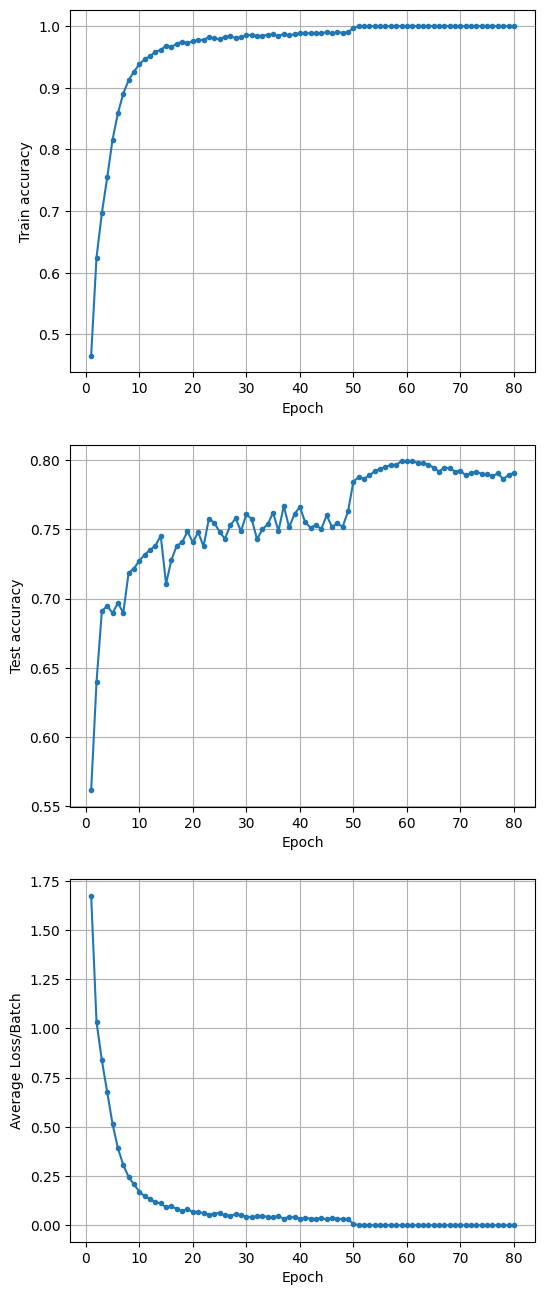

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
fig, axs = plt.subplots(3,1,figsize=(6, 16))
# fig.suptitle('[Emotions] Average Precision with various number of layers at mlp_head') #, fontdict={'fontsize': 10}, loc='center', )


#mlp_head with 2 layers
axs[0].plot([i for i in range(1, np.size(epoch_list)+1)],        train_acc_list_max, 'o-', markersize=3, label='train accuracy')
# axs[0].plot([i for i in range(1, results_mlp2_mean[:,2].size+1)],    results_mlp2_mean[:,2], 'o-', markersize=3, label='SSAST+Fusion mean pooling')
# axs[0].plot([i for i in range(1, results_mlp2_meanmax[:,2].size+1)], results_mlp2_meanmax[:,2], 'o-', markersize=3, label='SSAST+Fusion mean+max pooling')
# axs[0].plot([i for i in range(1, results_mlp2_max[:,2].size+1)],     results_mlp2_max[:,2], 'o-', markersize=3, label='SSAST+Fusion max pooling')
# axs[0].plot([i for i in range(1, results_mlp2_maxmax[:,2].size+1)],  results_mlp2_maxmax[:,2], 'o-', markersize=3, label='SSAST+Fusion max+max pooling')
# axs[0].legend(loc=(0.40, 0.01), fontsize=9) #(1.04, 0) :outer loc
# plt.xticks(rotation=45)
# axs[0].set_xticks(np.arange(0, 50+1, 5)) #[Hyosun]results[:,0].size+1 해서 마지막 epoch 보이게
# axs[0].set_yticks(np.arange(0, np.max(results_mlp2_maxmax[:,0])+0.05, 0.001)) #, rotation=45)
# axs[0].set_ylim(0.216, 0.234)
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Train accuracy')
axs[0].grid(True, linestyle='-')
# axs[0].set_title('Train accuracy', fontdict={'fontsize': 10}, loc='center', )
# fig.savefig('[IurbanEvent]Accuracy_num-layers_mlphead.png',dpi=300)

#mlp_head with 4 layers
axs[1].plot([i for i in range(1, np.size(epoch_list)+1)],        test_acc_list_max, 'o-', markersize=3, label='test accuracy')
# axs[1].plot([i for i in range(1, results_mlp4_mean[:,2].size+1)],    results_mlp4_mean[:,2], 'o-', markersize=3, label='SSAST+Fusion mean pooling')
# axs[1].plot([i for i in range(1, results_mlp4_meanmax[:,2].size+1)], results_mlp4_meanmax[:,2], 'o-', markersize=3, label='SSAST+Fusion mean+max pooling')
# axs[1].plot([i for i in range(1, results_mlp4_max[:,2].size+1)],     results_mlp4_max[:,2], 'o-', markersize=3, label='SSAST+Fusion max pooling')
# axs[1].plot([i for i in range(1, results_mlp4_maxmax[:,2].size+1)],  results_mlp4_maxmax[:,2], 'o-', markersize=3, label='SSAST+Fusion max+max pooling')
# axs[1].legend(loc=(0.40, 0.01), fontsize=9) #(1.04, 0) :outer loc
# plt.xticks(rotation=45)
# axs[1].set_xticks(np.arange(0, 50+1, 5)) #[Hyosun]results[:,0].size+1 해서 마지막 epoch 보이게
# axs[1].set_yticks(np.arange(0, np.max(results_mlp4_maxmax[:,2])+0.05, 0.001)) #, rotation=45)
# axs[1].set_ylim(0.212, 0.234)
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Test accuracy')
axs[1].grid(True, linestyle='-')
# axs[1].set_title('Test accuracy', fontdict={'fontsize': 10}, loc='center', )
# fig.savefig('[IurbanEvent]Accuracy_num-layers_mlphead.png',dpi=300)

#mlp_head with 6 layers
axs[2].plot([i for i in range(1, np.size(epoch_list)+1)],        avg_loss_batch_list_max, 'o-', markersize=3, label='average loss/batch')
# axs[2].plot([i for i in range(1, results_mlp6_mean[:,2].size+1)],    results_mlp6_mean[:,2], 'o-', markersize=3, label='SSAST+Fusion mean pooling')
# axs[2].plot([i for i in range(1, results_mlp6_meanmax[:,2].size+1)], results_mlp6_meanmax[:,2], 'o-', markersize=3, label='SSAST+Fusion mean+max pooling')
# axs[2].plot([i for i in range(1, results_mlp6_max[:,2].size+1)],     results_mlp6_max[:,2], 'o-', markersize=3, label='SSAST+Fusion max pooling')
# axs[2].plot([i for i in range(1, results_mlp6_maxmax[:,2].size+1)],  results_mlp6_maxmax[:,2], 'o-', markersize=3, label='SSAST+Fusion max+max pooling')
# axs[2].legend(loc=(0.40, 0.01), fontsize=9) #(1.04, 0) :outer loc
# plt.xticks(rotation=45)
# axs[2].set_xticks(np.arange(0, 50+1, 5)) #[Hyosun]results[:,0].size+1 해서 마지막 epoch 보이게
# axs[2].set_yticks(np.arange(0, np.max(results_mlp6_maxmax[:,2])+0.05, 0.001)) #, rotation=45)
# axs[2].set_ylim(0.216, 0.234)
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('Average Loss/Batch')
axs[2].grid(True, linestyle='-')
# axs[2].set_title('Average Loss/Batch', fontdict={'fontsize': 10}, loc='center', )


fig.savefig('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/model/'+ data_name +'/' + current_file_name+ 'VGG19_transfer_train_test_acc_loss.png',dpi=300)

# The original VGG19

In [ ]:
net = Vgg19(data_len=23035, no_labels=10, data_name = "tau", load_data_version="v1", fusion_type="") # data_len=len(data), no_labels=3, by CHS
net.train(shuffle_flag=True)
# net.train(shuffle_flag=False)

Streaming output truncated to the last 5000 lines.
What is the size of train_data?: 18428
current_batch: [6000 6001 6002 6003 6004 6005 6006 6007 6008 6009]
current_batch_real_indices_from_the_whole_dataset: [13059  6137 16472 12622 20860  2531  4082 17318 17481  7735]
j:  601
What is the size of train_data?: 18428
current_batch: [6010 6011 6012 6013 6014 6015 6016 6017 6018 6019]
current_batch_real_indices_from_the_whole_dataset: [ 1614 17329 13934 16371 11472  1578  9881 13981 19598 21668]
j:  602
What is the size of train_data?: 18428
current_batch: [6020 6021 6022 6023 6024 6025 6026 6027 6028 6029]
current_batch_real_indices_from_the_whole_dataset: [19568 13441  7295 11262 22433  3948  2976  3063   603 18114]
j:  603
What is the size of train_data?: 18428
current_batch: [6030 6031 6032 6033 6034 6035 6036 6037 6038 6039]
current_batch_real_indices_from_the_whole_dataset: [10816 16029 13878 21549 19736 13228  1320 10293 22021  2707]
j:  604
What is the size of train_data?: 18428
cu

In [ ]:
import os
data_name = "tau"
current_file = 'logs_proposedVGG19_tau_v1__2024-09-18.txt'
current_file_name, ext =current_file.split('.')
# Open and extract the lines of the data file
with open(os.path.join('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/model/', data_name, current_file), 'r') as f:
    lines = f.readlines()
f.close()

epoch_list, train_acc_list, test_acc_list, avg_loss_batch_list = [], [], [], []
# loop through lines of the file
i=0
for line in lines:
    # remove newline and extract data from line
    if i>39:
        print(line)
        eval = line.strip().split(' ')
        print(eval)
        epoch_list.append(int(eval[1]))
        train_acc_list.append(float(eval[4]))
        test_acc_list.append(float(eval[7]))
        avg_loss_batch_list.append(float(eval[10]))
        print("epoch: %s, train_acc: %s, test_acc: %s, avg_loss_batch: %s" % (eval[1], eval[4], eval[7], eval[10]))
    i+=1
    # print

Epoch: 0 Train Acc: 0.281094 Test Acc: 0.394400 Average Loss/Batch: 1.922379 precision_train: 0.317397 recall_train: 0.317397 f1_train: 0.317397 precision_test: 0.394400 recall_test: 0.394400 f1_test: 0.394400

['Epoch:', '0', 'Train', 'Acc:', '0.281094', 'Test', 'Acc:', '0.394400', 'Average', 'Loss/Batch:', '1.922379', 'precision_train:', '0.317397', 'recall_train:', '0.317397', 'f1_train:', '0.317397', 'precision_test:', '0.394400', 'recall_test:', '0.394400', 'f1_test:', '0.394400']
epoch: 0, train_acc: 0.281094, test_acc: 0.394400, avg_loss_batch: 1.922379
Epoch: 1 Train Acc: 0.430052 Test Acc: 0.489255 Average Loss/Batch: 1.483825 precision_train: 0.469449 recall_train: 0.469449 f1_train: 0.469449 precision_test: 0.489255 recall_test: 0.489255 f1_test: 0.489255

['Epoch:', '1', 'Train', 'Acc:', '0.430052', 'Test', 'Acc:', '0.489255', 'Average', 'Loss/Batch:', '1.483825', 'precision_train:', '0.469449', 'recall_train:', '0.469449', 'f1_train:', '0.469449', 'precision_test:', '0.489

In [ ]:
train_acc_list

[0.281094,
 0.430052,
 0.501954,
 0.56056,
 0.608096,
 0.643423,
 0.68206,
 0.711689,
 0.743271,
 0.774691,
 0.795203,
 0.819514,
 0.843716,
 0.862221,
 0.875787,
 0.889516,
 0.898307,
 0.910571,
 0.91578,
 0.926308,
 0.931517,
 0.934936,
 0.94313,
 0.944867,
 0.94758,
 0.951704,
 0.952952,
 0.957402,
 0.957239,
 0.957782,
 0.961852,
 0.964945,
 0.957348,
 0.968472,
 0.96234,
 0.96641,
 0.968146,
 0.96679,
 0.967387,
 0.960224,
 0.97341,
 0.973519,
 0.969394,
 0.972162,
 0.973573,
 0.972216,
 0.97303,
 0.967115,
 0.978077,
 0.991969,
 0.999566,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

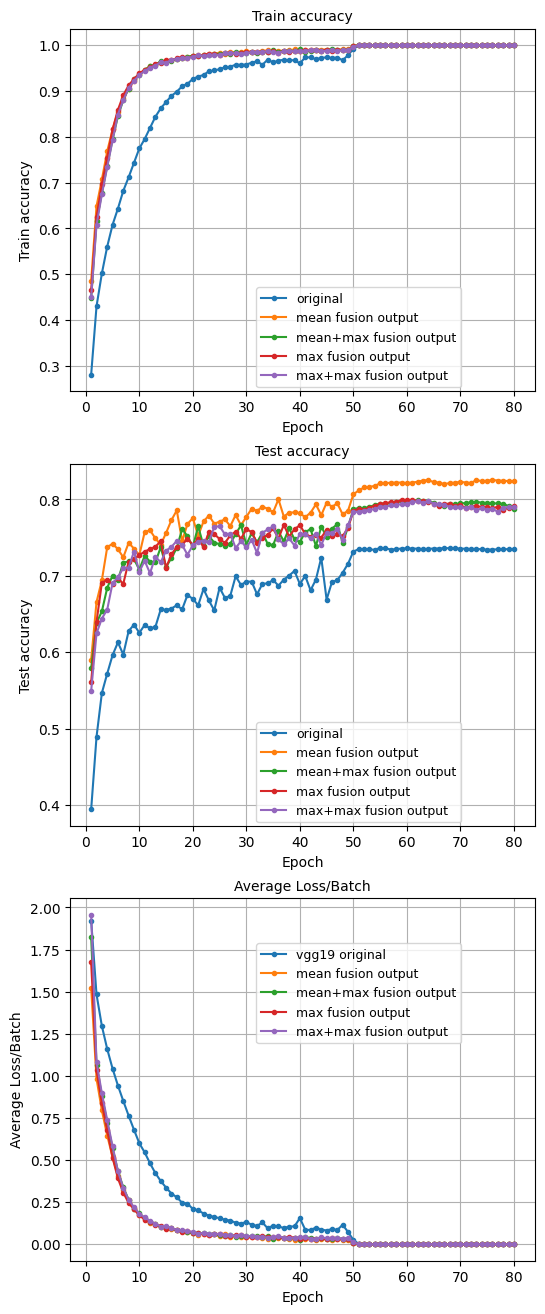

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import date #2024-09-16
fig, axs = plt.subplots(3,1,figsize=(6, 16))
# fig.suptitle('[Emotions] Average Precision with various number of layers at mlp_head') #, fontdict={'fontsize': 10}, loc='center', )

data_name = "tau" #2024-09-16
#mlp_head with 2 layers
axs[0].plot([i for i in range(1, np.size(epoch_list)+1)],        train_acc_list, 'o-', markersize=3, label='original')
axs[0].plot([i for i in range(1, np.size(epoch_list)+1)],        train_acc_list_mean, 'o-', markersize=3, label='mean fusion output')
axs[0].plot([i for i in range(1, np.size(epoch_list)+1)],        train_acc_list_mean_max, 'o-', markersize=3, label='mean+max fusion output')
axs[0].plot([i for i in range(1, np.size(epoch_list)+1)],        train_acc_list_max, 'o-', markersize=3, label='max fusion output')
axs[0].plot([i for i in range(1, np.size(epoch_list)+1)],        train_acc_list_max_max, 'o-', markersize=3, label='max+max fusion output')
# axs[0].plot([i for i in range(1, results_mlp2_mean[:,2].size+1)],    results_mlp2_mean[:,2], 'o-', markersize=3, label='SSAST+Fusion mean pooling')
# axs[0].plot([i for i in range(1, results_mlp2_meanmax[:,2].size+1)], results_mlp2_meanmax[:,2], 'o-', markersize=3, label='SSAST+Fusion mean+max pooling')
# axs[0].plot([i for i in range(1, results_mlp2_max[:,2].size+1)],     results_mlp2_max[:,2], 'o-', markersize=3, label='SSAST+Fusion max pooling')
# axs[0].plot([i for i in range(1, results_mlp2_maxmax[:,2].size+1)],  results_mlp2_maxmax[:,2], 'o-', markersize=3, label='SSAST+Fusion max+max pooling')
axs[0].legend(loc=(0.40, 0.01), fontsize=9) #(1.04, 0) :outer loc
# plt.xticks(rotation=45)
# axs[0].set_xticks(np.arange(0, 50+1, 5)) #[Hyosun]results[:,0].size+1 해서 마지막 epoch 보이게
# axs[0].set_yticks(np.arange(0, np.max(results_mlp2_maxmax[:,0])+0.05, 0.001)) #, rotation=45)
# axs[0].set_ylim(0.216, 0.234)
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Train accuracy')
axs[0].grid(True, linestyle='-')
axs[0].set_title('Train accuracy', fontdict={'fontsize': 10}, loc='center', )
# fig.savefig('[IurbanEvent]Accuracy_num-layers_mlphead.png',dpi=300)

#mlp_head with 4 layers
axs[1].plot([i for i in range(1, np.size(epoch_list)+1)],        test_acc_list, 'o-', markersize=3, label='original')
axs[1].plot([i for i in range(1, np.size(epoch_list)+1)],        test_acc_list_mean, 'o-', markersize=3, label='mean fusion output')
axs[1].plot([i for i in range(1, np.size(epoch_list)+1)],        test_acc_list_mean_max, 'o-', markersize=3, label='mean+max fusion output')
axs[1].plot([i for i in range(1, np.size(epoch_list)+1)],        test_acc_list_max, 'o-', markersize=3, label='max fusion output')
axs[1].plot([i for i in range(1, np.size(epoch_list)+1)],        test_acc_list_max_max, 'o-', markersize=3, label='max+max fusion output')
# axs[1].plot([i for i in range(1, results_mlp4_mean[:,2].size+1)],    results_mlp4_mean[:,2], 'o-', markersize=3, label='SSAST+Fusion mean pooling')
# axs[1].plot([i for i in range(1, results_mlp4_meanmax[:,2].size+1)], results_mlp4_meanmax[:,2], 'o-', markersize=3, label='SSAST+Fusion mean+max pooling')
# axs[1].plot([i for i in range(1, results_mlp4_max[:,2].size+1)],     results_mlp4_max[:,2], 'o-', markersize=3, label='SSAST+Fusion max pooling')
# axs[1].plot([i for i in range(1, results_mlp4_maxmax[:,2].size+1)],  results_mlp4_maxmax[:,2], 'o-', markersize=3, label='SSAST+Fusion max+max pooling')
axs[1].legend(loc=(0.40, 0.01), fontsize=9) #(1.04, 0) :outer loc
# plt.xticks(rotation=45)
# axs[1].set_xticks(np.arange(0, 50+1, 5)) #[Hyosun]results[:,0].size+1 해서 마지막 epoch 보이게
# axs[1].set_yticks(np.arange(0, np.max(results_mlp4_maxmax[:,2])+0.05, 0.001)) #, rotation=45)
# axs[1].set_ylim(0.212, 0.234)
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Test accuracy')
axs[1].grid(True, linestyle='-')
axs[1].set_title('Test accuracy', fontdict={'fontsize': 10}, loc='center', )
# fig.savefig('[IurbanEvent]Accuracy_num-layers_mlphead.png',dpi=300)

#mlp_head with 6 layers
axs[2].plot([i for i in range(1, np.size(epoch_list)+1)],        avg_loss_batch_list, 'o-', markersize=3, label='vgg19 original')
axs[2].plot([i for i in range(1, np.size(epoch_list)+1)],        avg_loss_batch_list_mean, 'o-', markersize=3, label='mean fusion output')
axs[2].plot([i for i in range(1, np.size(epoch_list)+1)],        avg_loss_batch_list_mean_max, 'o-', markersize=3, label='mean+max fusion output')
axs[2].plot([i for i in range(1, np.size(epoch_list)+1)],        avg_loss_batch_list_max, 'o-', markersize=3, label='max fusion output')
axs[2].plot([i for i in range(1, np.size(epoch_list)+1)],        avg_loss_batch_list_max_max, 'o-', markersize=3, label='max+max fusion output')
# axs[2].plot([i for i in range(1, results_mlp6_mean[:,2].size+1)],    results_mlp6_mean[:,2], 'o-', markersize=3, label='SSAST+Fusion mean pooling')
# axs[2].plot([i for i in range(1, results_mlp6_meanmax[:,2].size+1)], results_mlp6_meanmax[:,2], 'o-', markersize=3, label='SSAST+Fusion mean+max pooling')
# axs[2].plot([i for i in range(1, results_mlp6_max[:,2].size+1)],     results_mlp6_max[:,2], 'o-', markersize=3, label='SSAST+Fusion max pooling')
# axs[2].plot([i for i in range(1, results_mlp6_maxmax[:,2].size+1)],  results_mlp6_maxmax[:,2], 'o-', markersize=3, label='SSAST+Fusion max+max pooling')
axs[2].legend(loc=(0.40, 0.60), fontsize=9) #(1.04, 0) :outer loc
# plt.xticks(rotation=45)
# axs[2].set_xticks(np.arange(0, 50+1, 5)) #[Hyosun]results[:,0].size+1 해서 마지막 epoch 보이게
# axs[2].set_yticks(np.arange(0, np.max(results_mlp6_maxmax[:,2])+0.05, 0.001)) #, rotation=45)
# axs[2].set_ylim(0.216, 0.234)
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('Average Loss/Batch')
axs[2].grid(True, linestyle='-')
axs[2].set_title('Average Loss/Batch', fontdict={'fontsize': 10}, loc='center', )


fig.savefig('/gdrive/MyDrive/ColabNotebooks/Github/TransferLearning/model/'+ data_name + '/' + 'TAU_all_fusion_type'+ str(date.today()) + 'VGG19_transfer_train_test_acc_loss.png',dpi=300)